In [1]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from tqdm import tqdm

In [2]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# anchor_radius sweep 范围
anchor_radii = range(2, 31, 2)  # 2,4,6,8,10

# 用于保存所有 radius 下的 dist_list 数量和指标
all_counts = {}
all_metrics = {}

os.makedirs("./fig", exist_ok=True)
os.makedirs("./csv", exist_ok=True)

Running with anchor_radius = 2...
cmd: ['../anchor_mapping', '--num_anchors', '100', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '2']
Running with anchor_radius = 4...
cmd: ['../anchor_mapping', '--num_anchors', '100', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '4']
Running with anchor_radius = 6...
cmd: ['../anchor_mapping', '--num_anchors', '100', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '6']
Running with anchor_radius = 8...
cmd: ['../anchor_mapping', '--num_anchors', '100', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '8']
Running with anchor_radius = 10...
cmd: ['../anchor_mapping', '--num_anchors', '100', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--

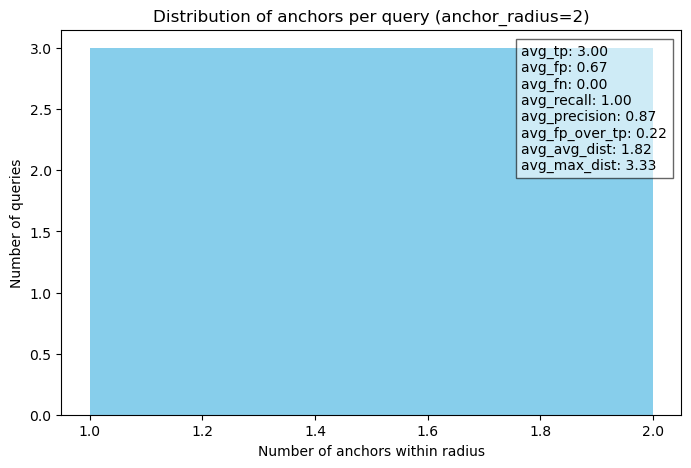

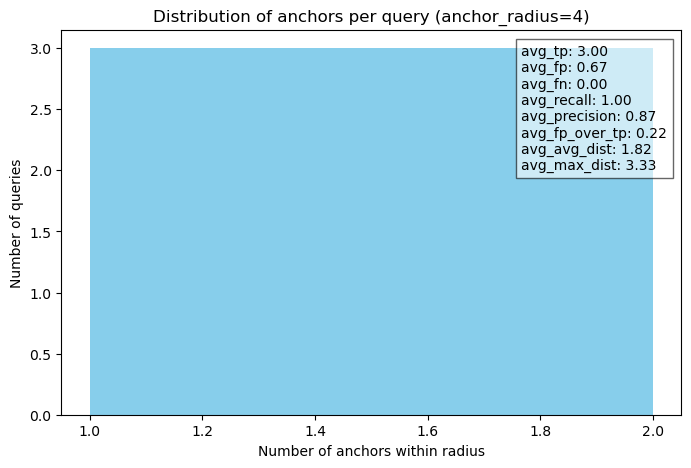

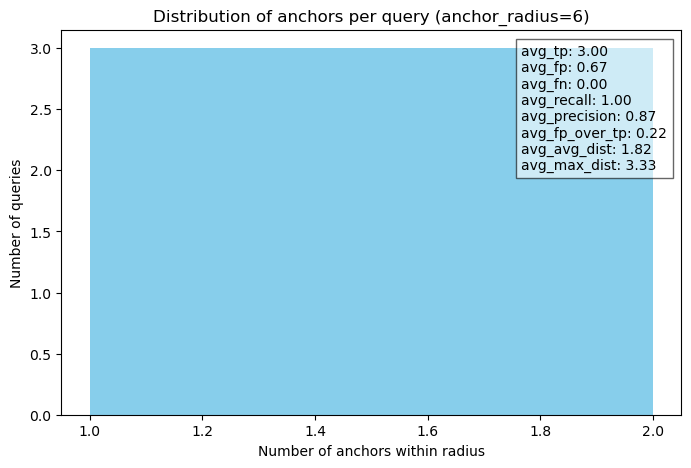

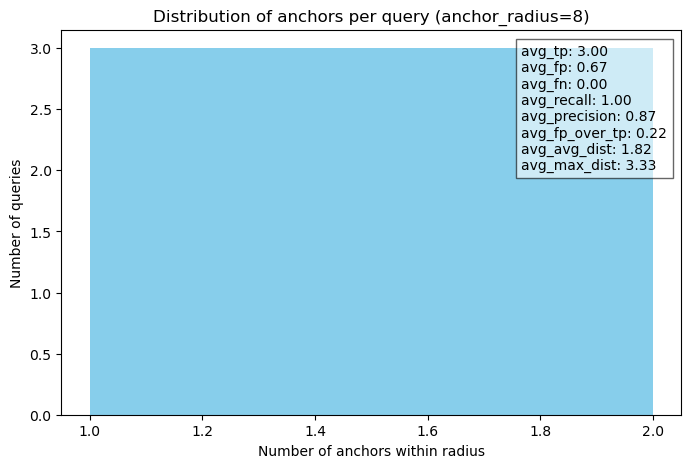

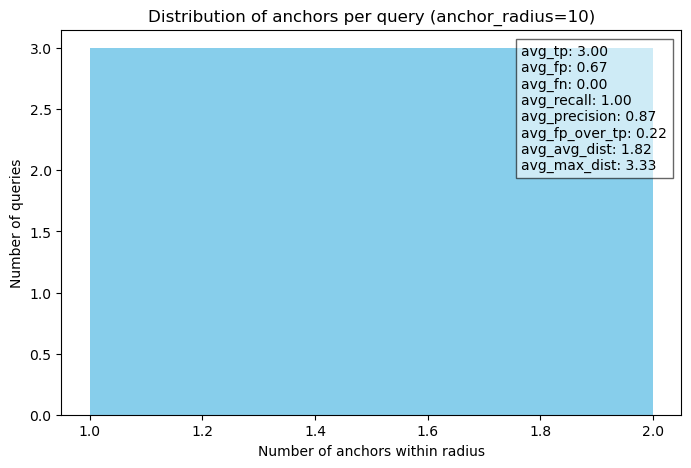

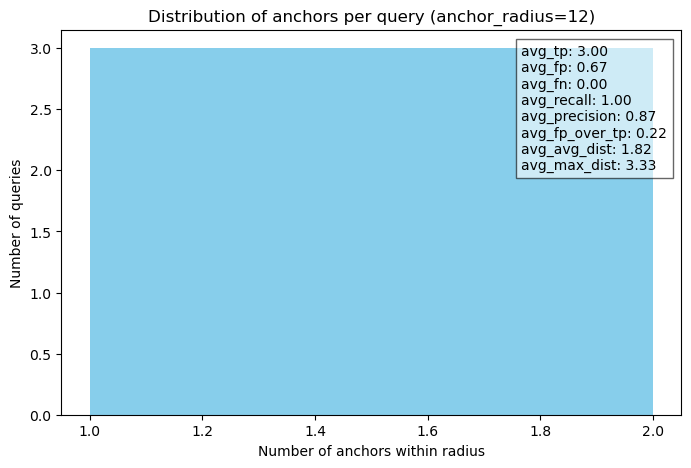

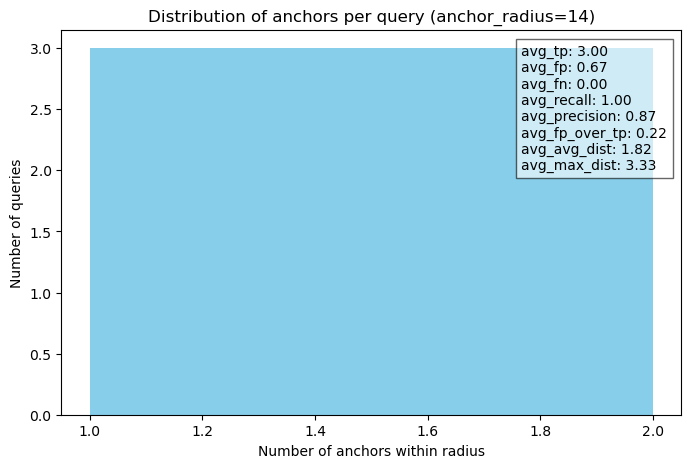

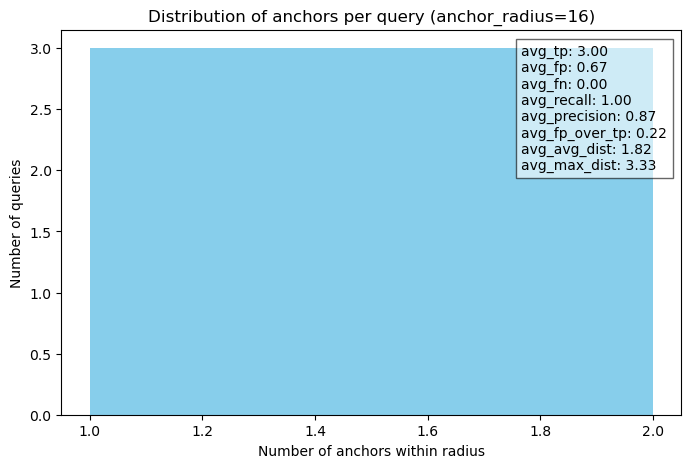

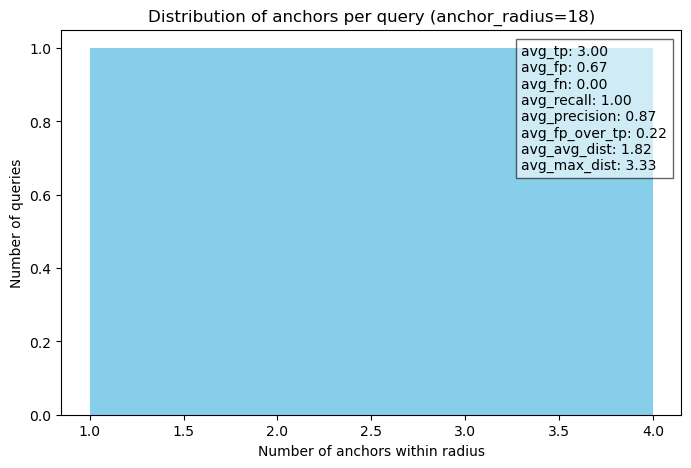

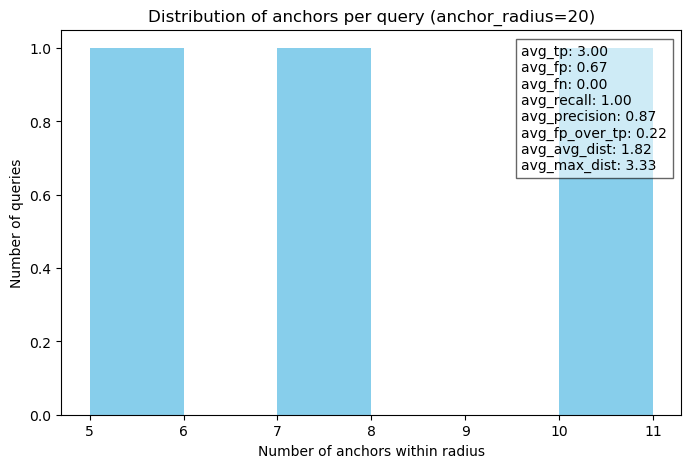

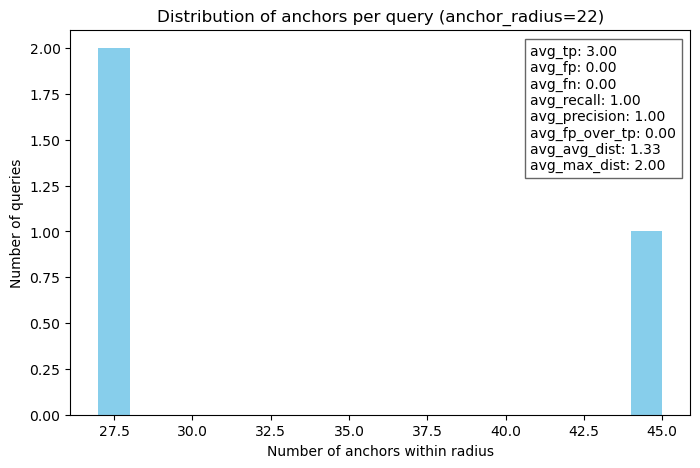

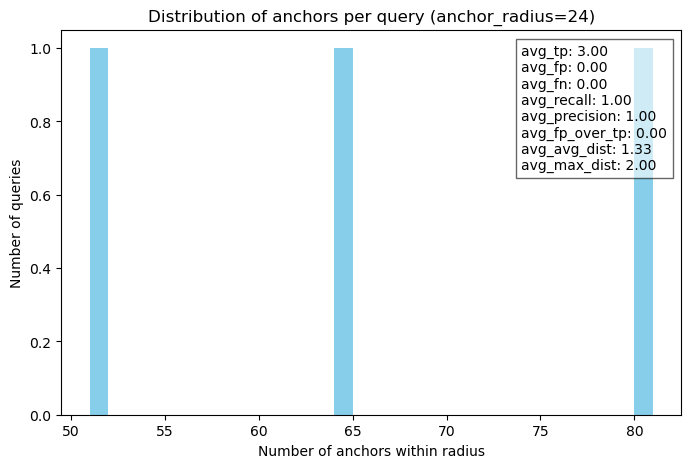

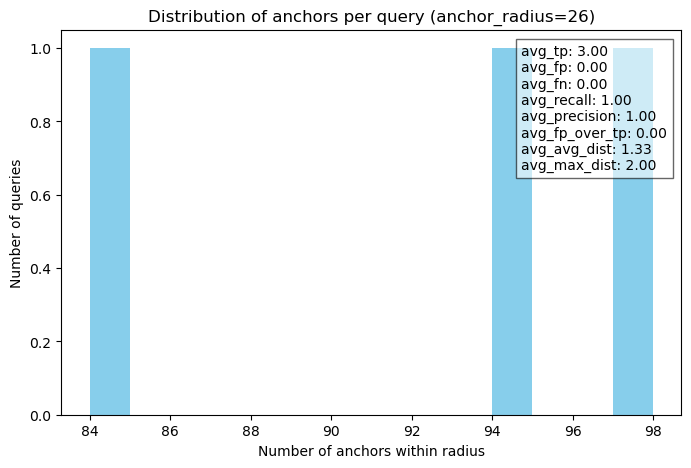

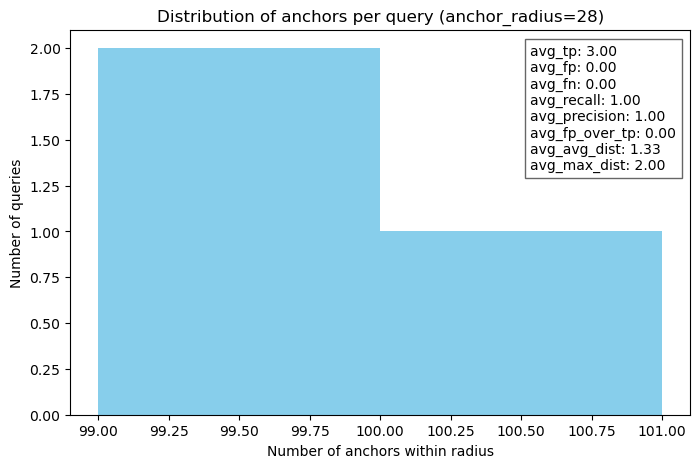

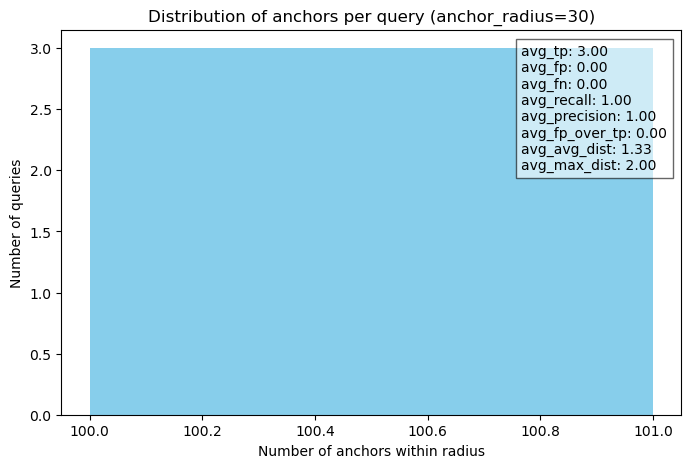

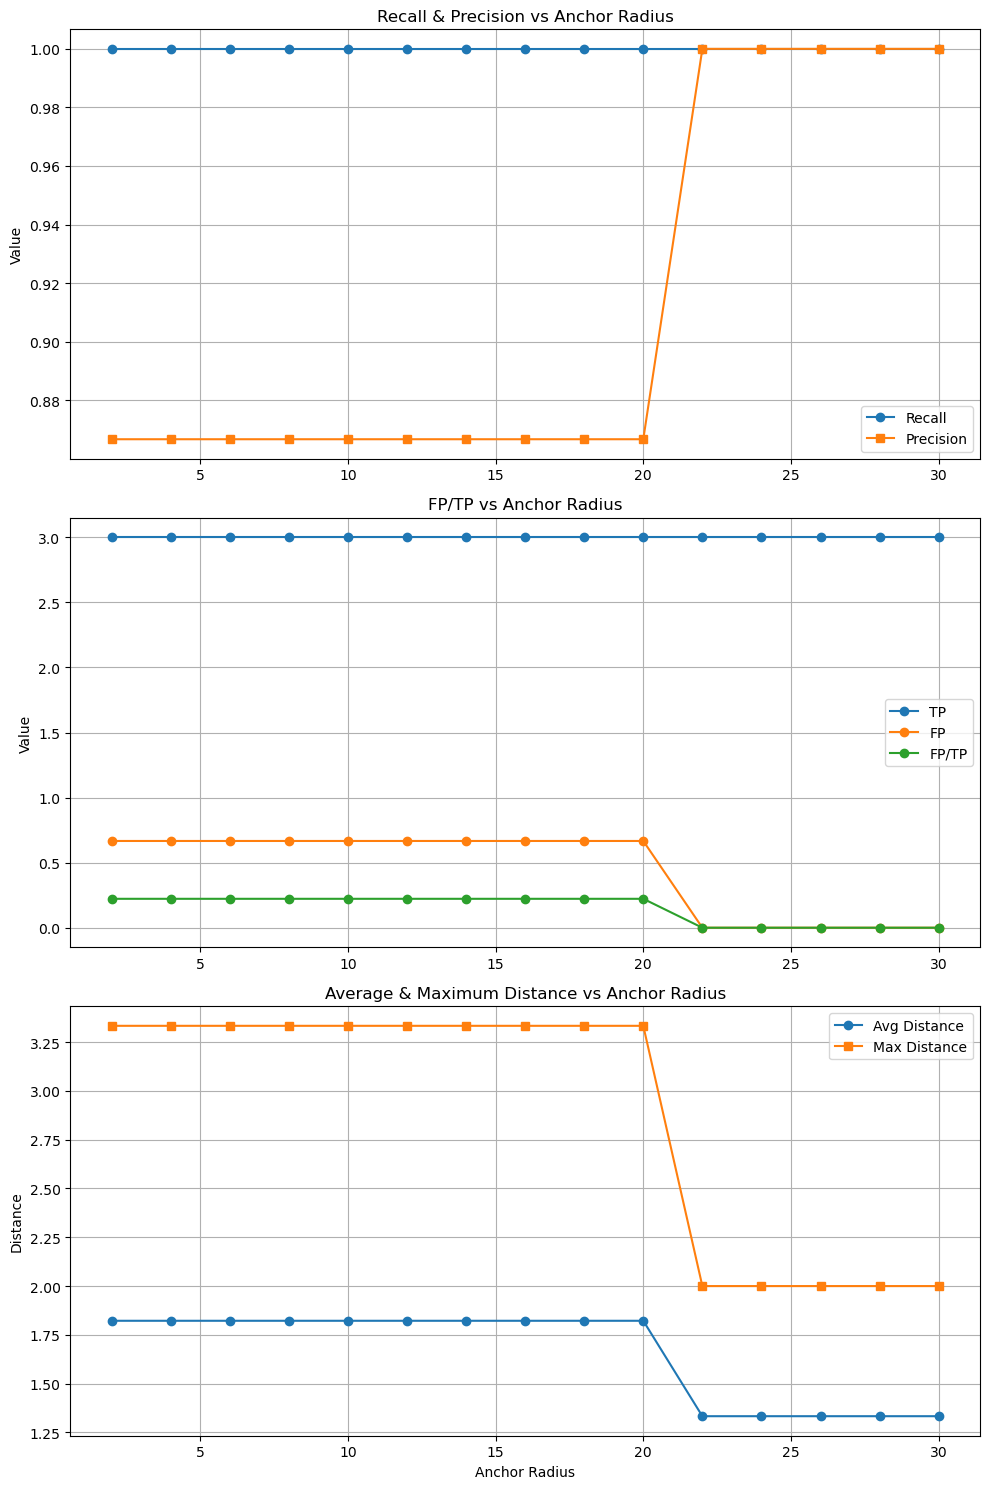

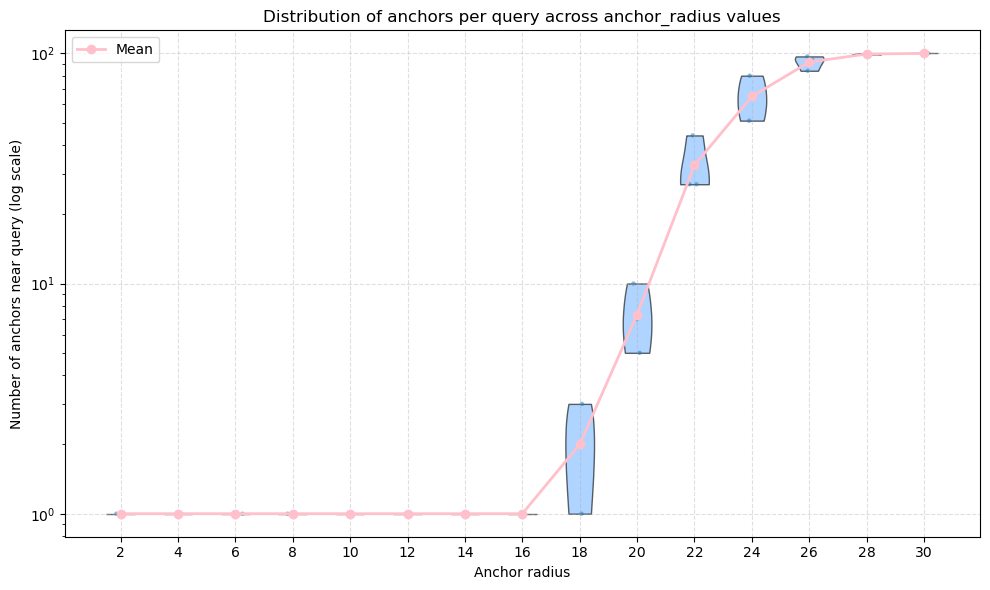

Running with anchor_radius = 2...
cmd: ['../anchor_mapping', '--num_anchors', '500', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '2']
Running with anchor_radius = 4...
cmd: ['../anchor_mapping', '--num_anchors', '500', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '4']
Running with anchor_radius = 6...
cmd: ['../anchor_mapping', '--num_anchors', '500', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '6']
Running with anchor_radius = 8...
cmd: ['../anchor_mapping', '--num_anchors', '500', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '8']
Running with anchor_radius = 10...
cmd: ['../anchor_mapping', '--num_anchors', '500', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--

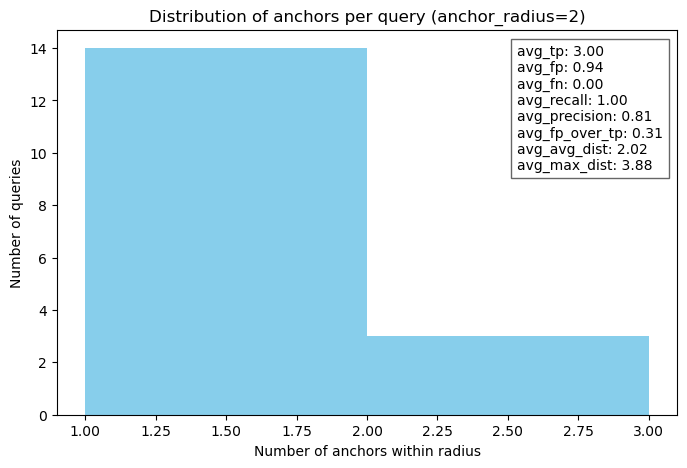

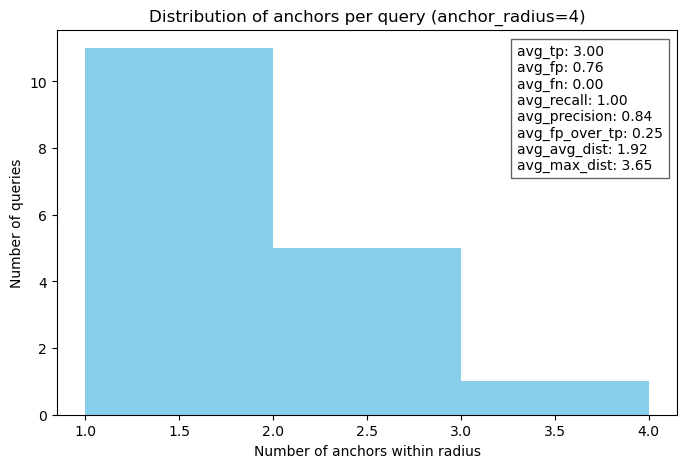

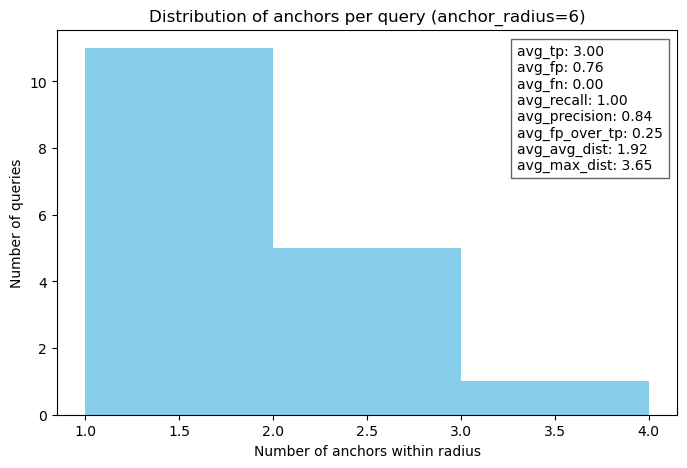

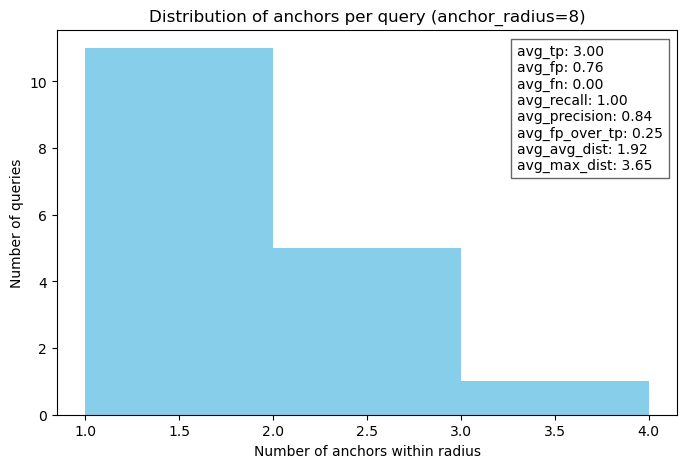

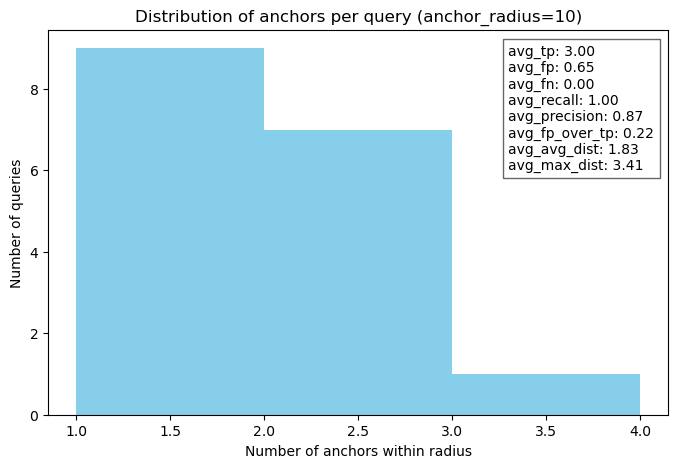

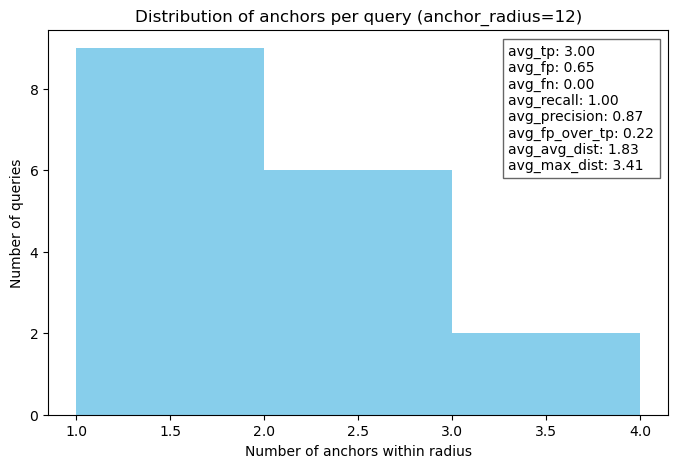

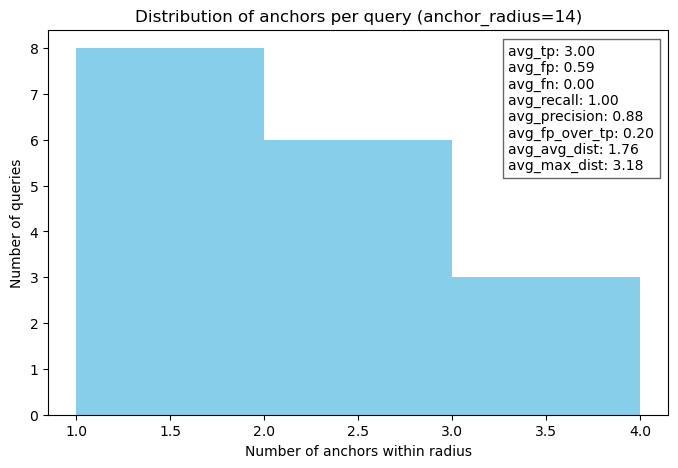

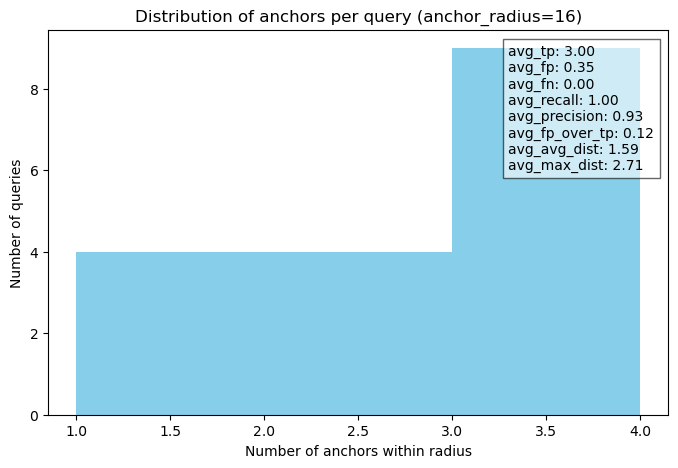

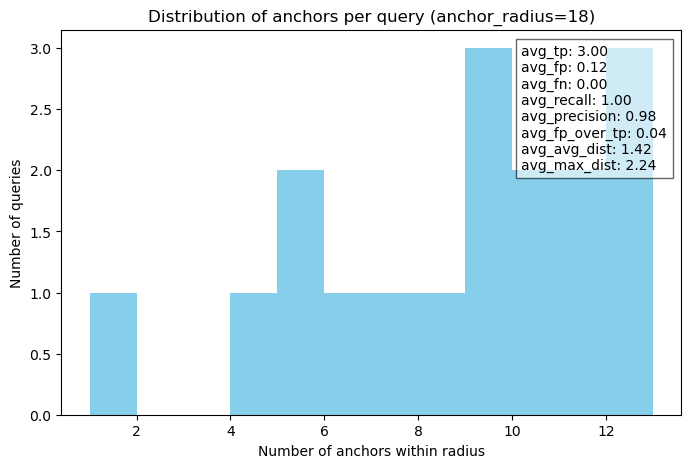

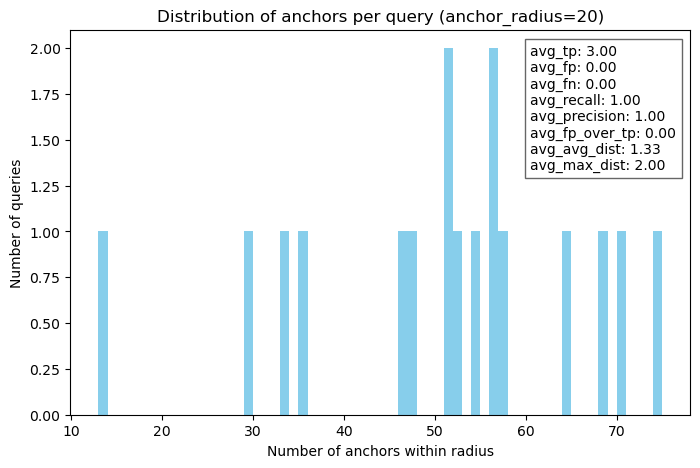

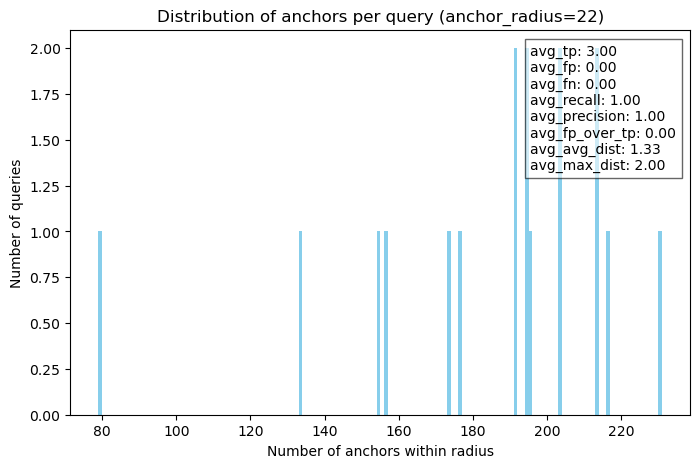

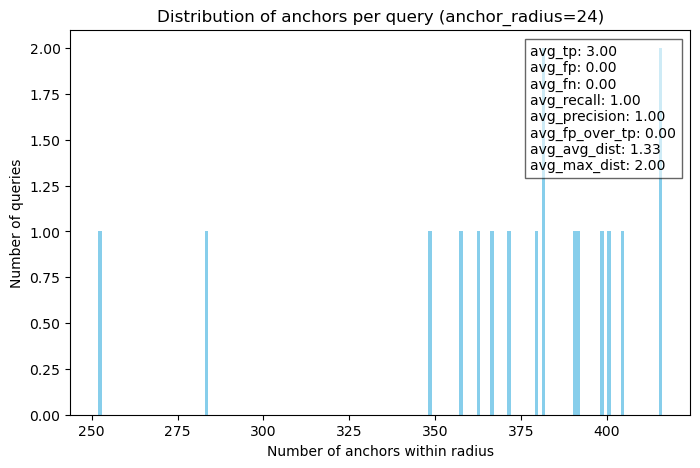

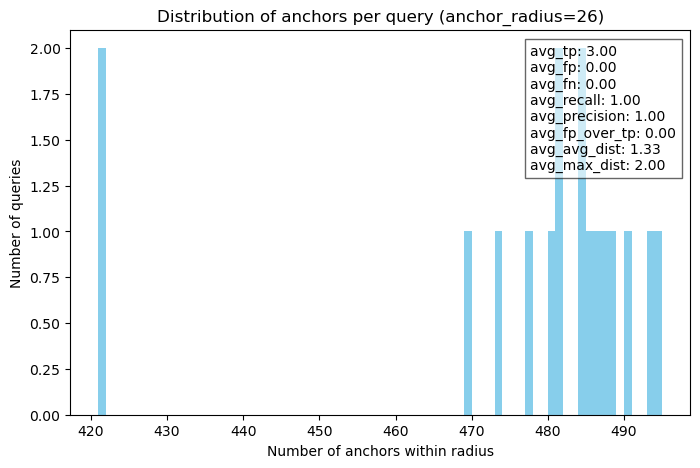

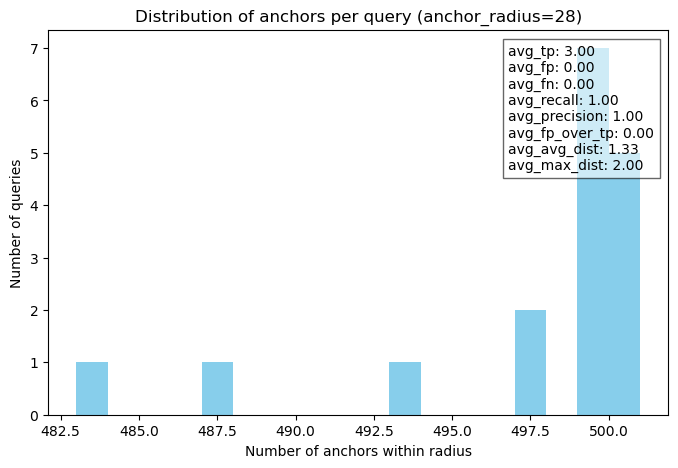

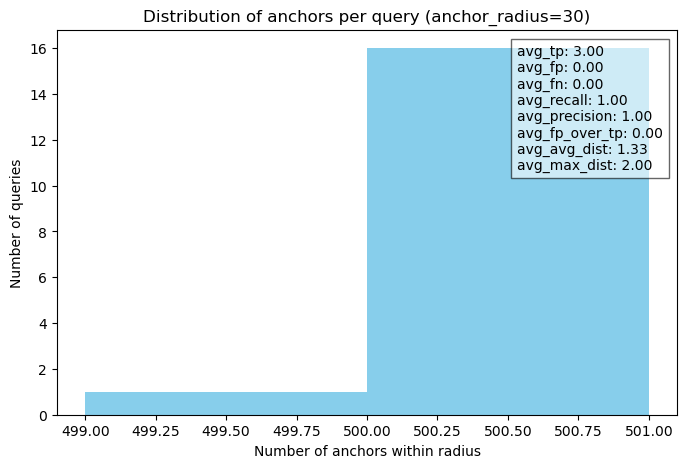

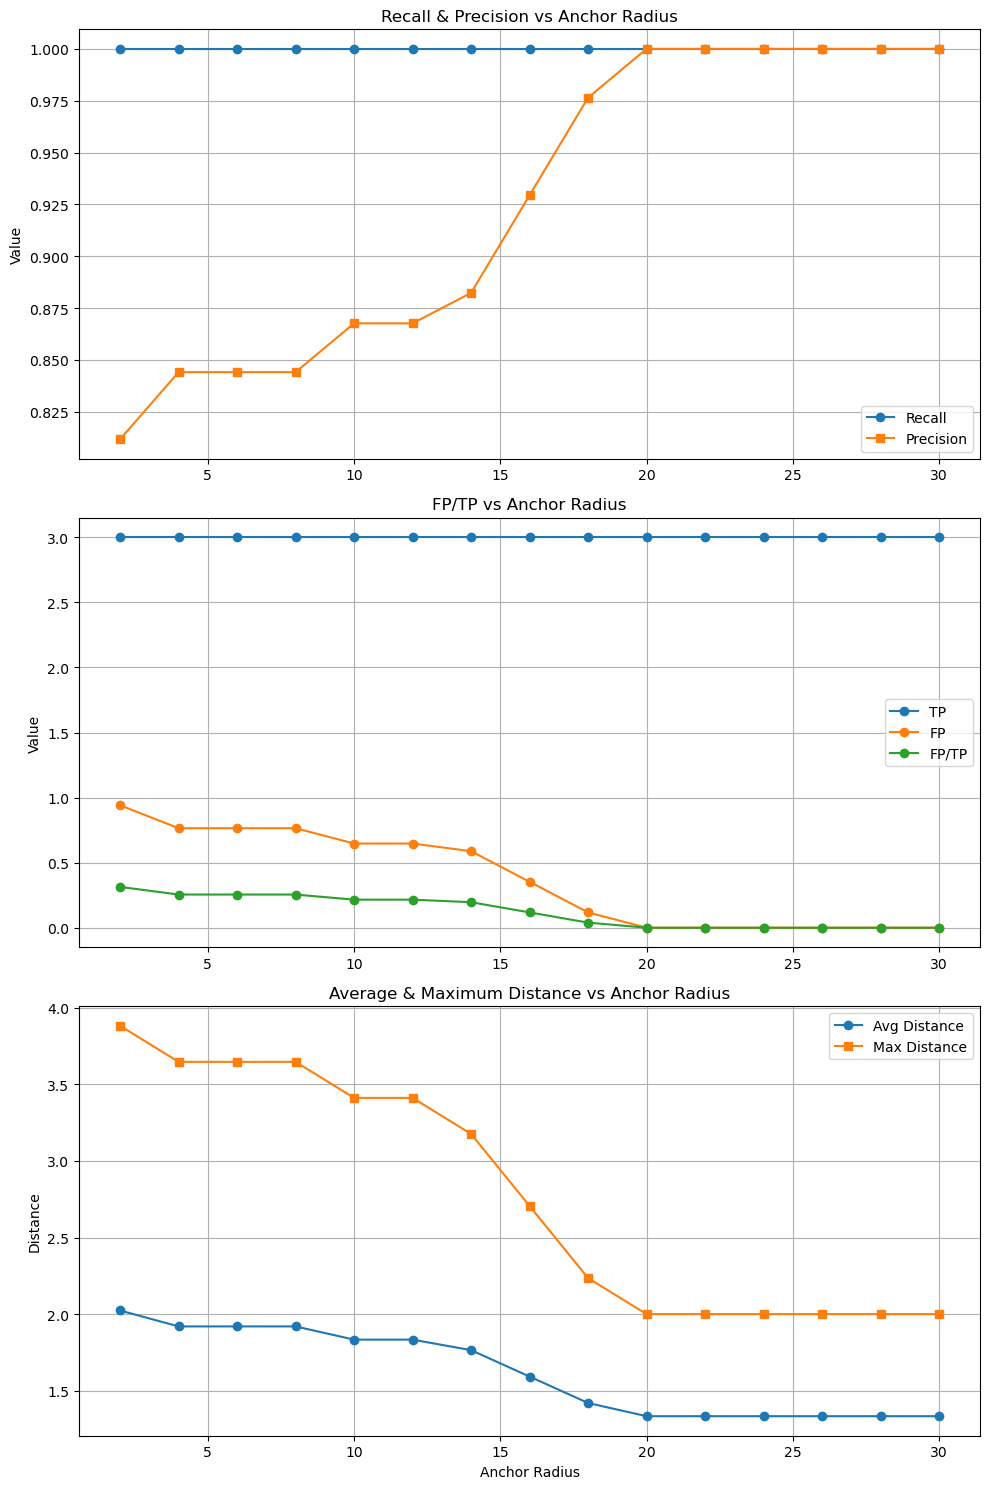

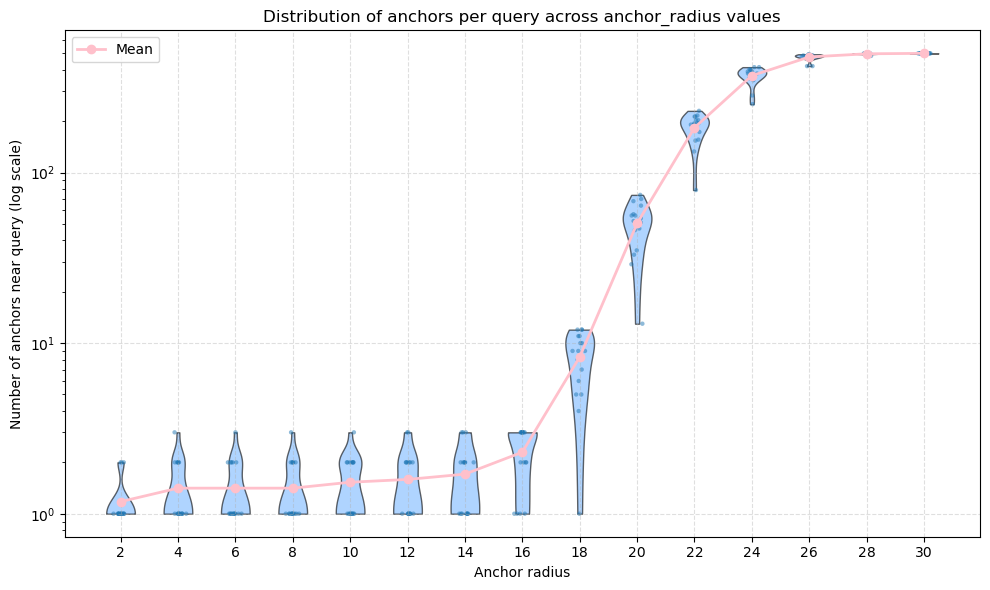

Running with anchor_radius = 2...
cmd: ['../anchor_mapping', '--num_anchors', '1000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '2']
Running with anchor_radius = 4...
cmd: ['../anchor_mapping', '--num_anchors', '1000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '4']
Running with anchor_radius = 6...
cmd: ['../anchor_mapping', '--num_anchors', '1000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '6']
Running with anchor_radius = 8...
cmd: ['../anchor_mapping', '--num_anchors', '1000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '8']
Running with anchor_radius = 10...
cmd: ['../anchor_mapping', '--num_anchors', '1000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2'

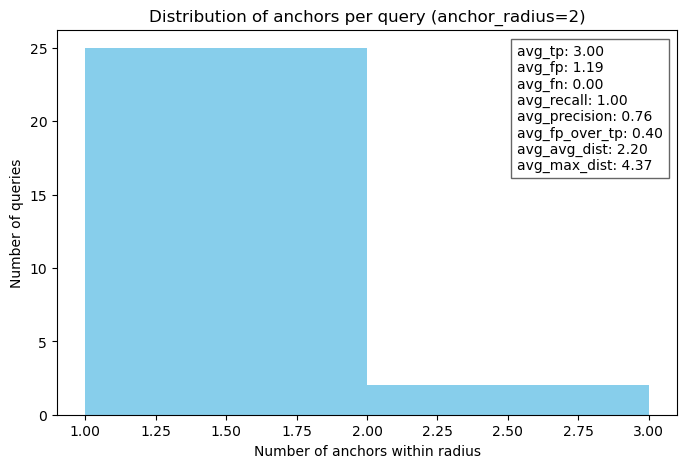

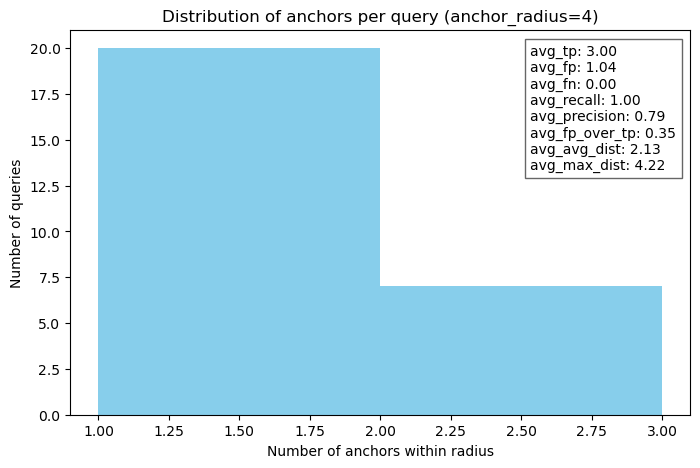

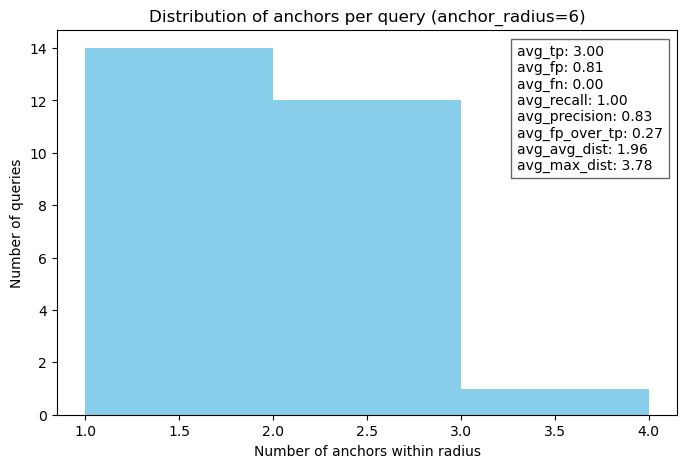

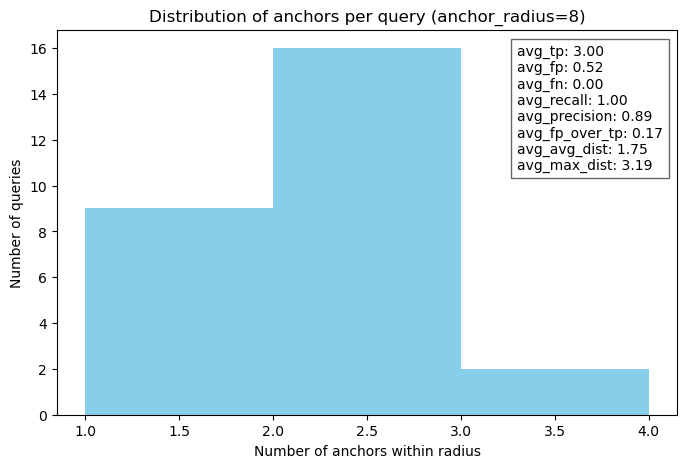

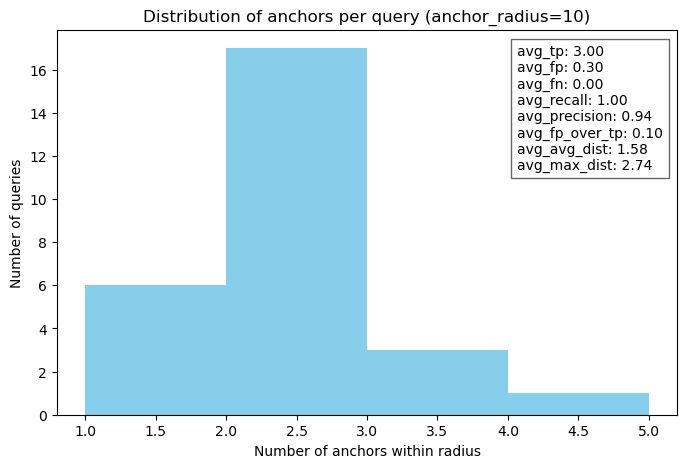

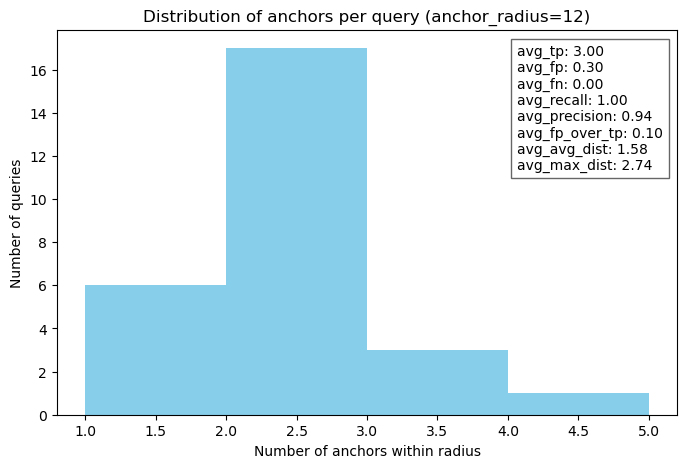

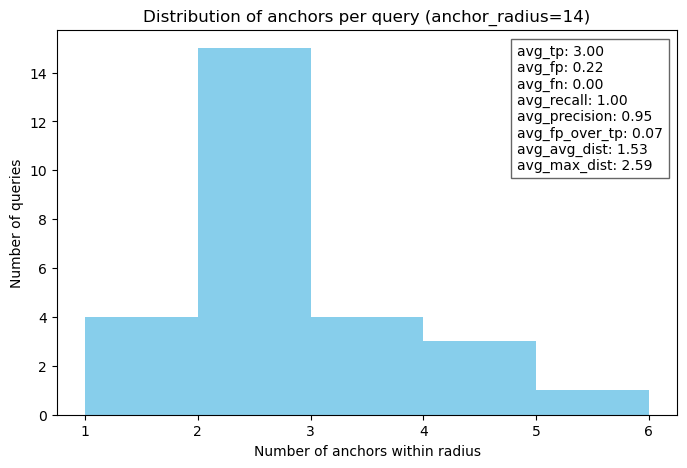

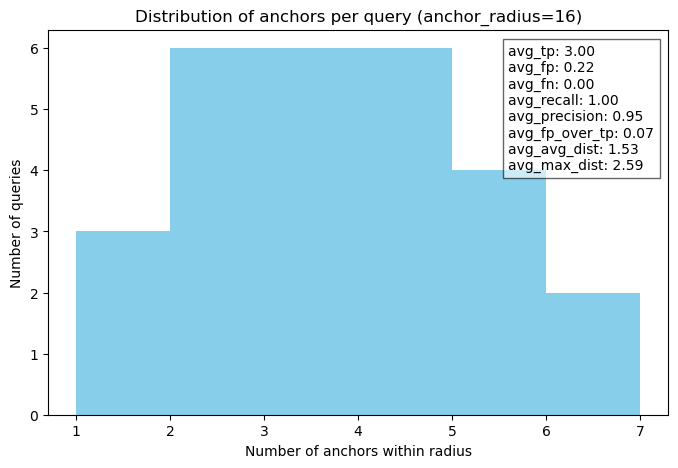

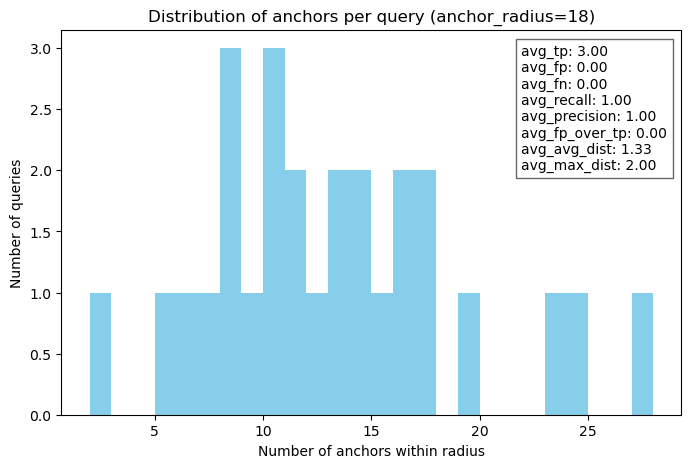

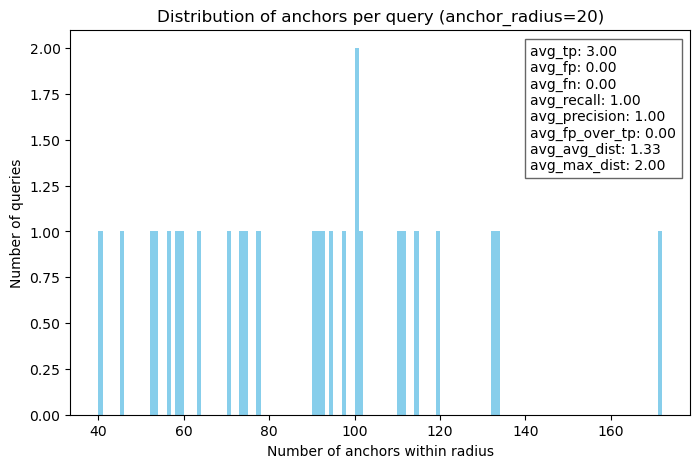

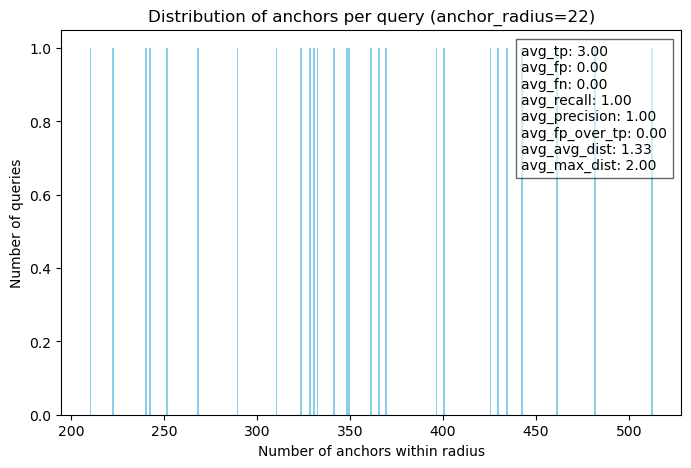

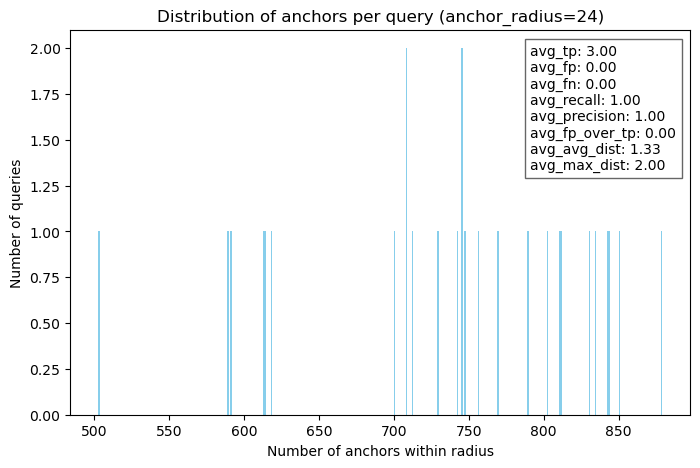

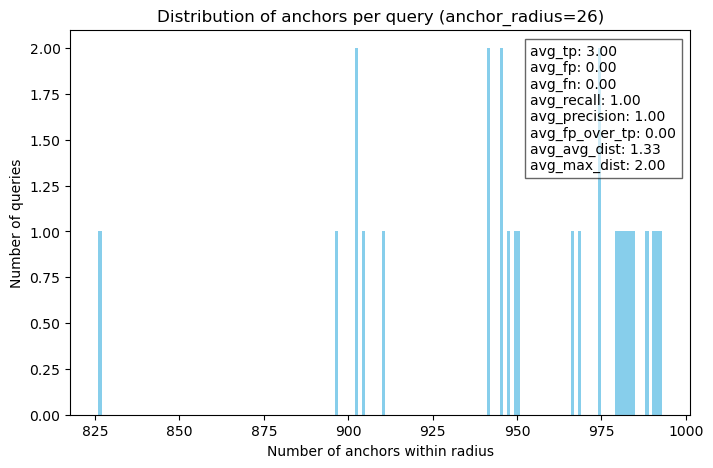

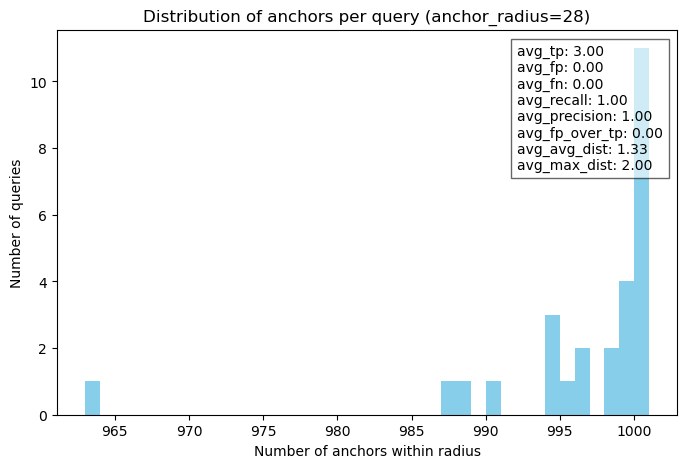

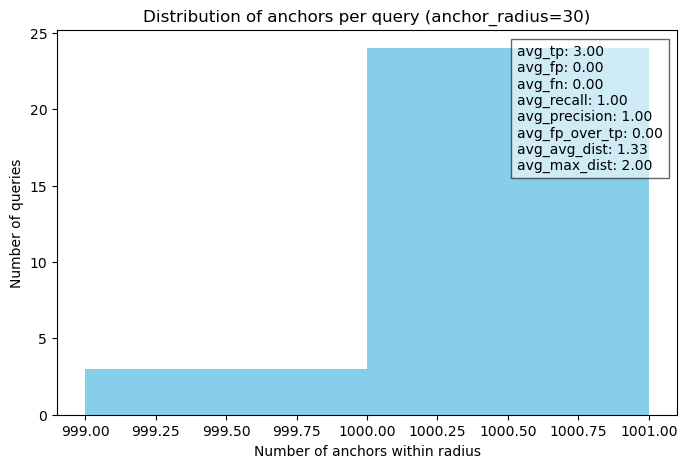

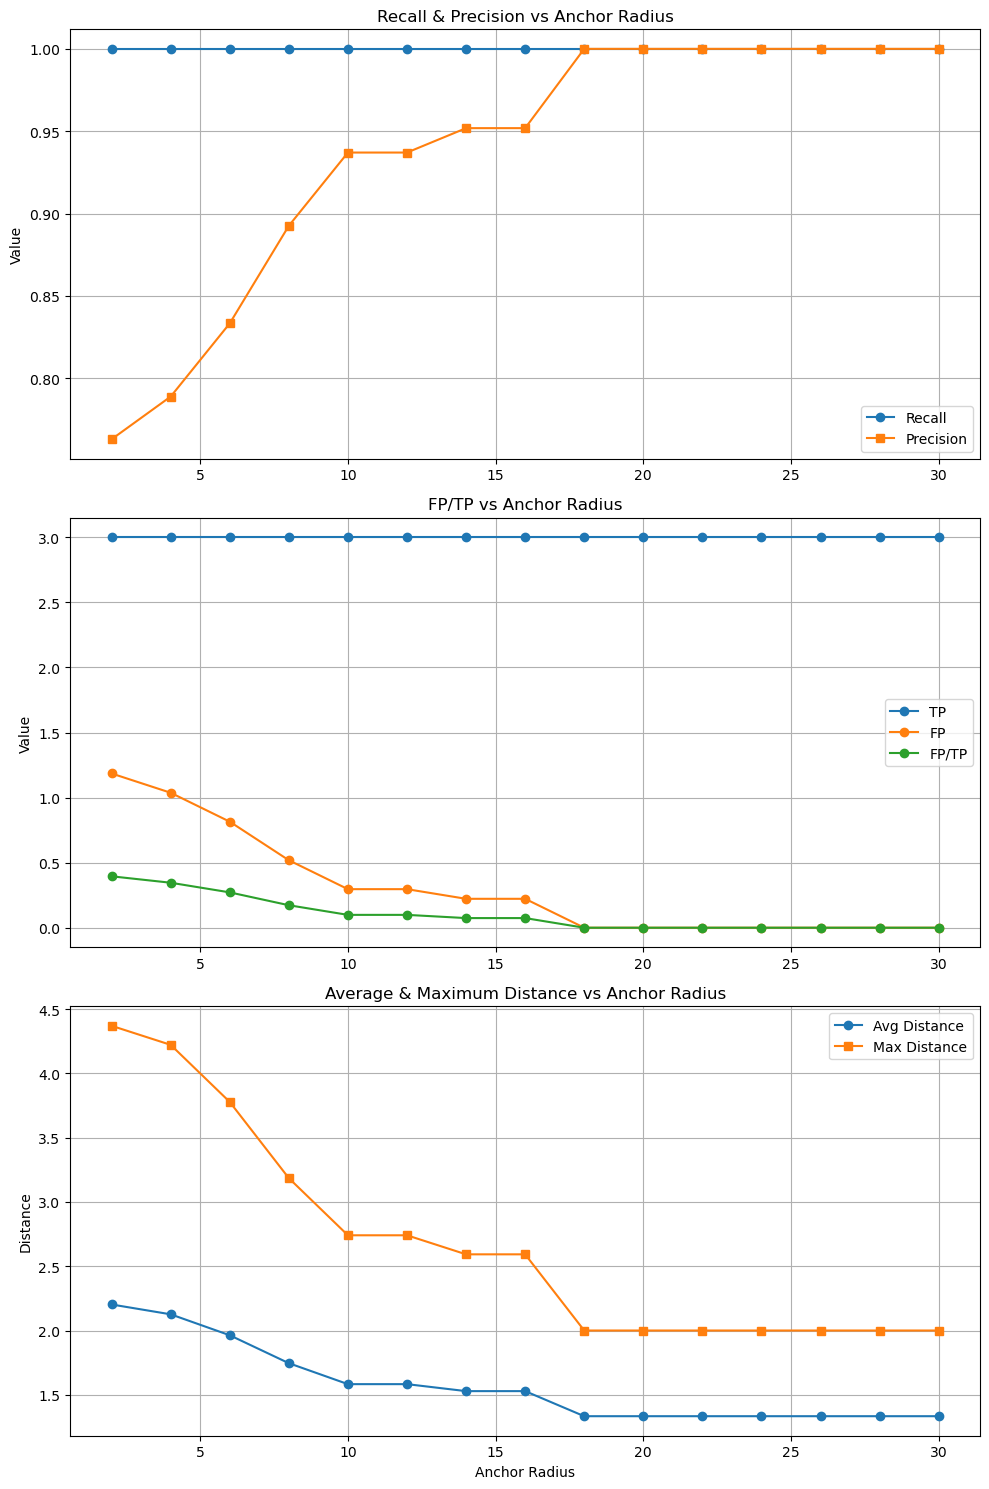

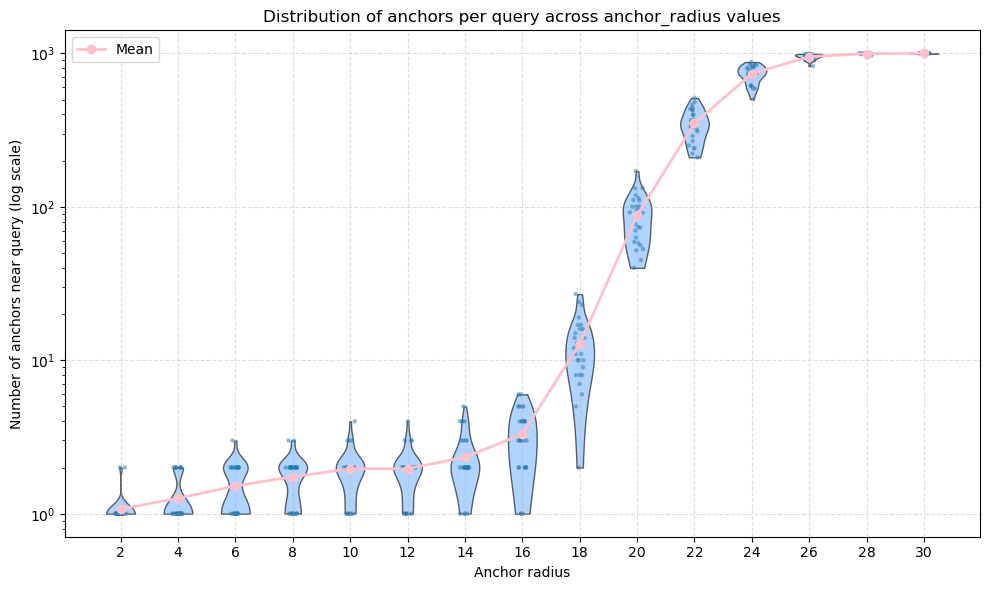

Running with anchor_radius = 2...
cmd: ['../anchor_mapping', '--num_anchors', '2000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '2']
Running with anchor_radius = 4...
cmd: ['../anchor_mapping', '--num_anchors', '2000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '4']
Running with anchor_radius = 6...
cmd: ['../anchor_mapping', '--num_anchors', '2000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '6']
Running with anchor_radius = 8...
cmd: ['../anchor_mapping', '--num_anchors', '2000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '8']
Running with anchor_radius = 10...
cmd: ['../anchor_mapping', '--num_anchors', '2000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2'

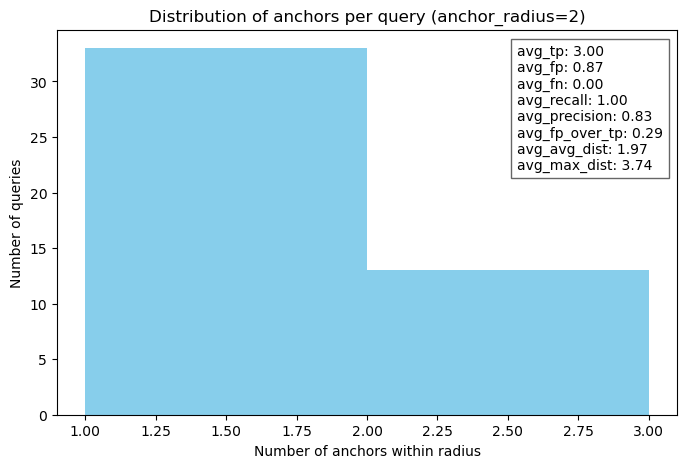

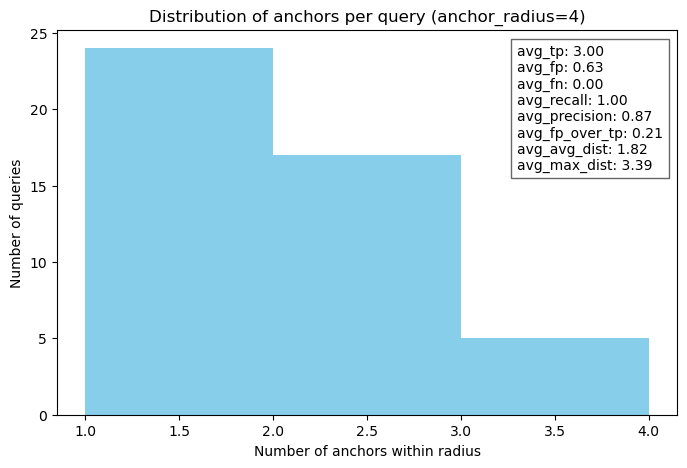

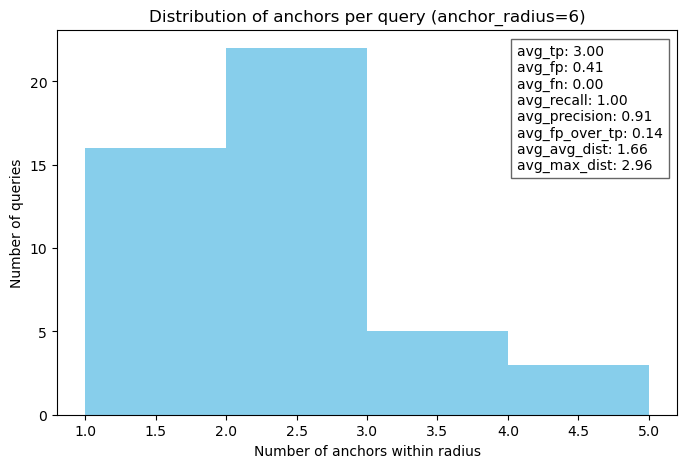

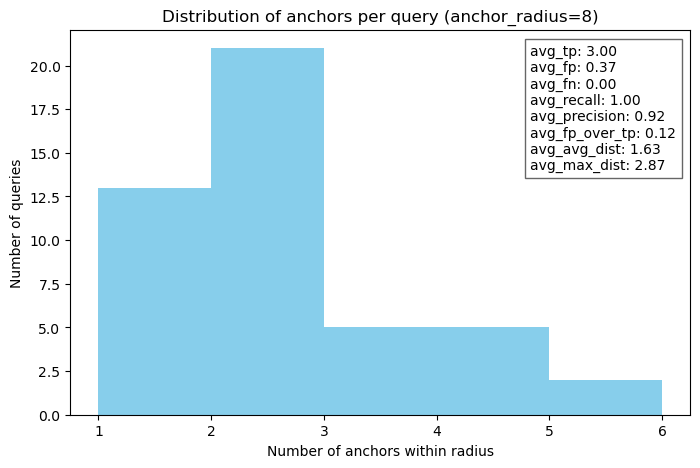

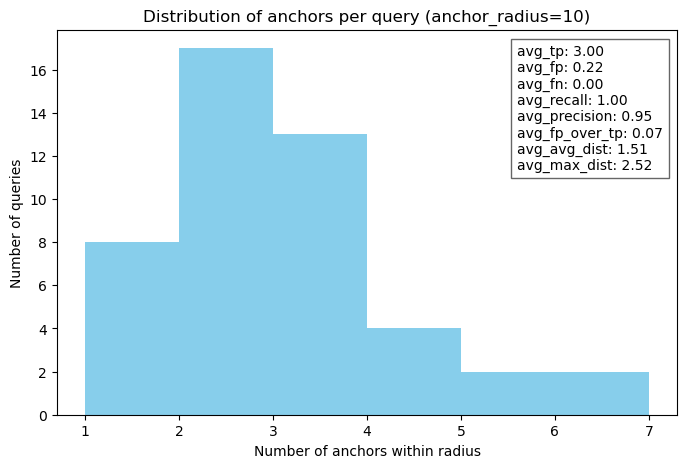

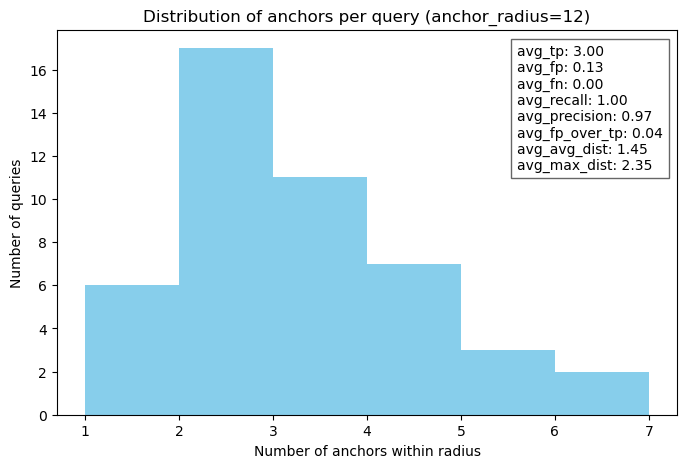

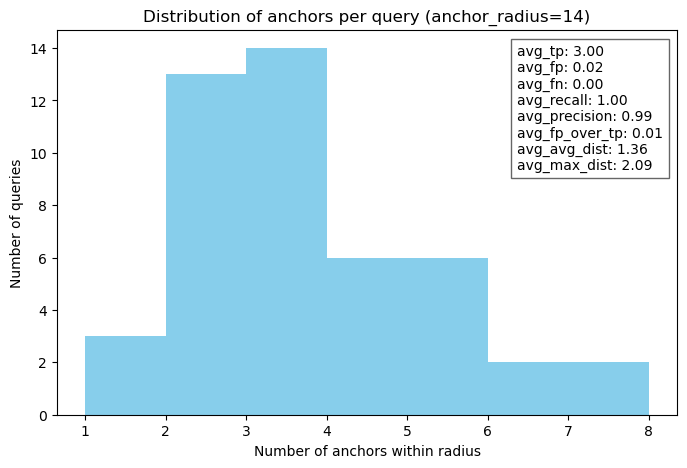

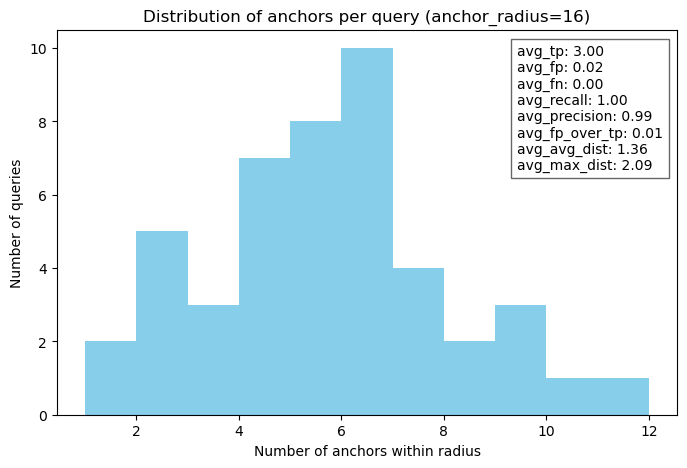

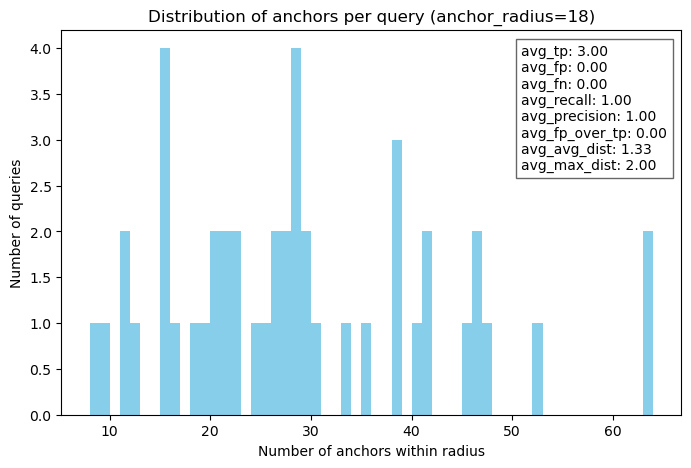

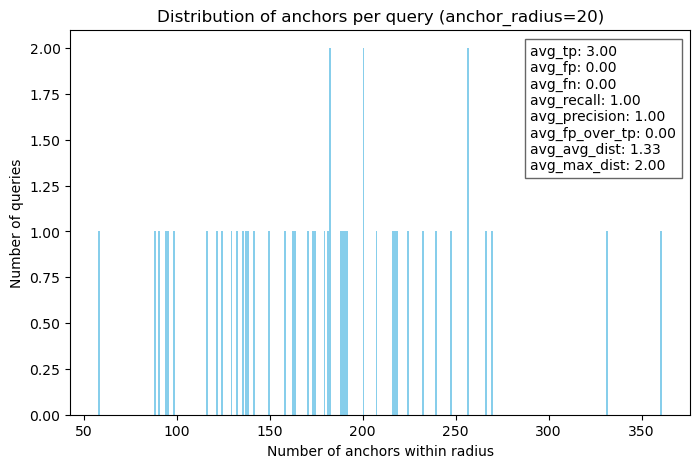

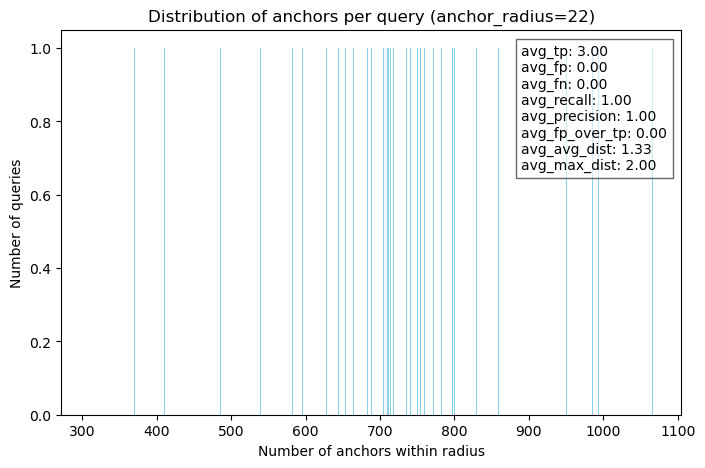

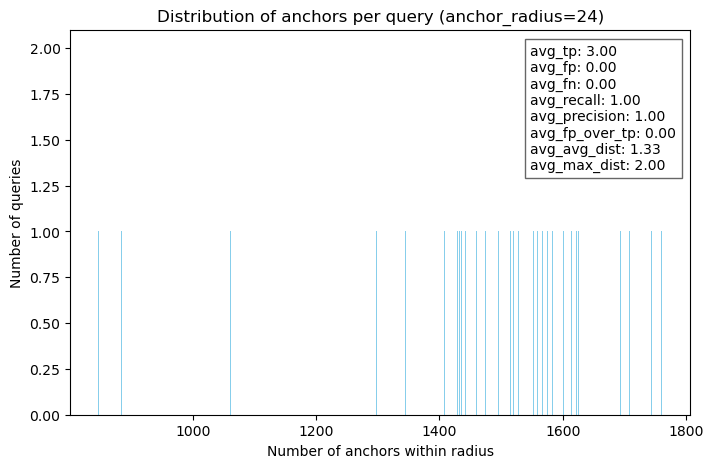

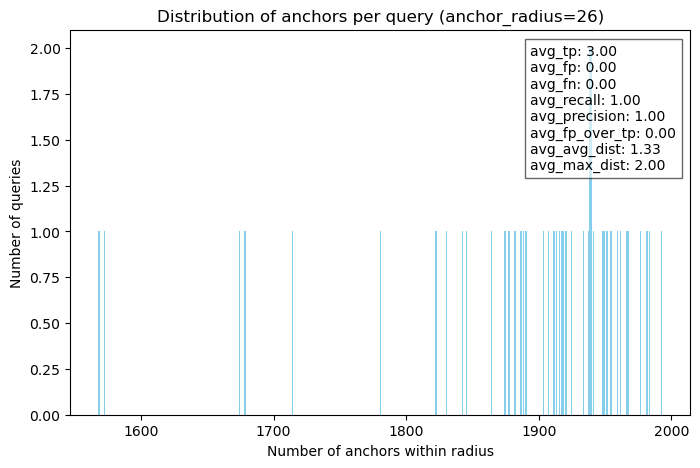

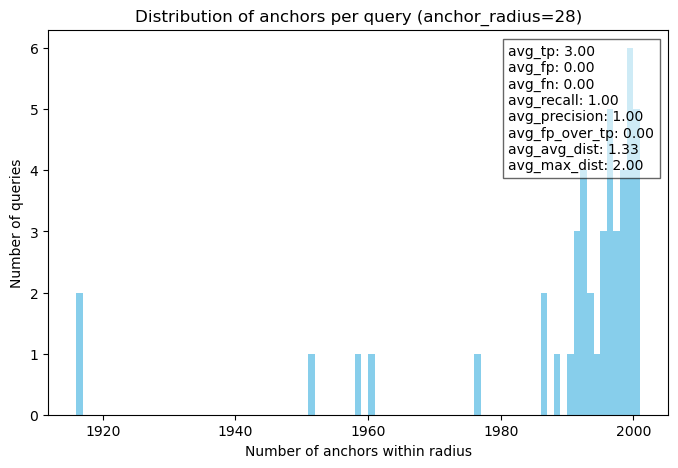

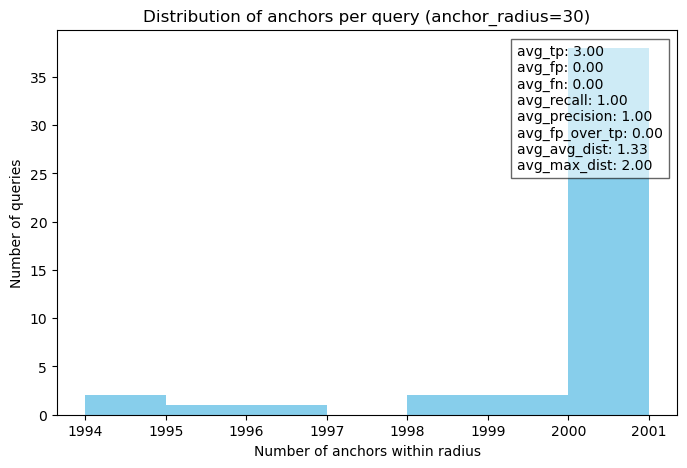

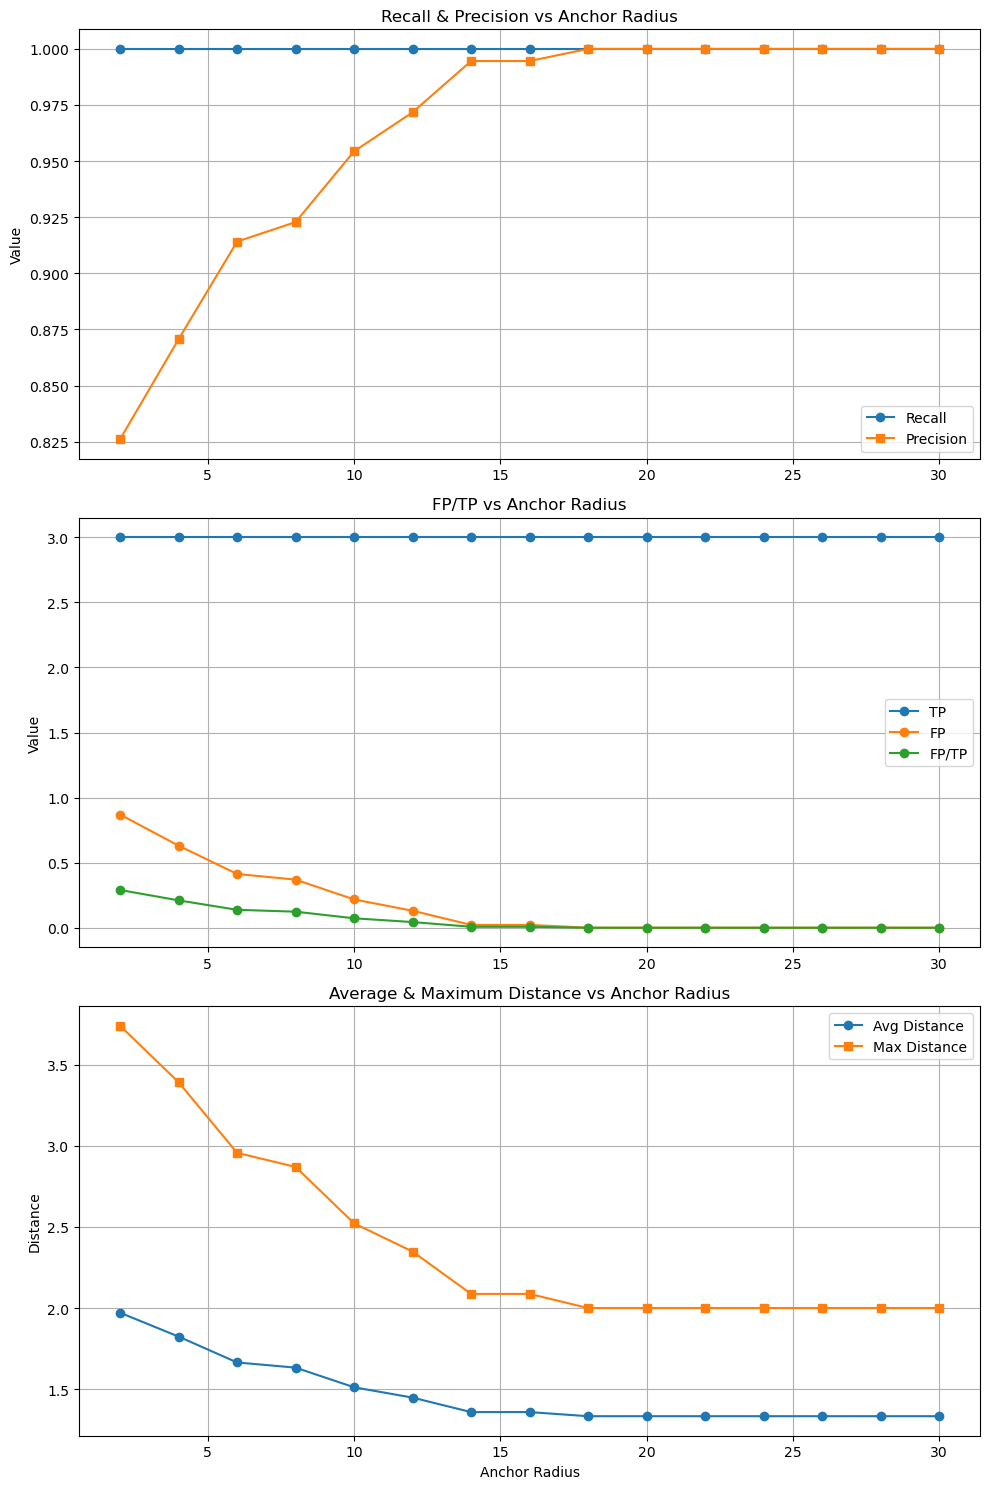

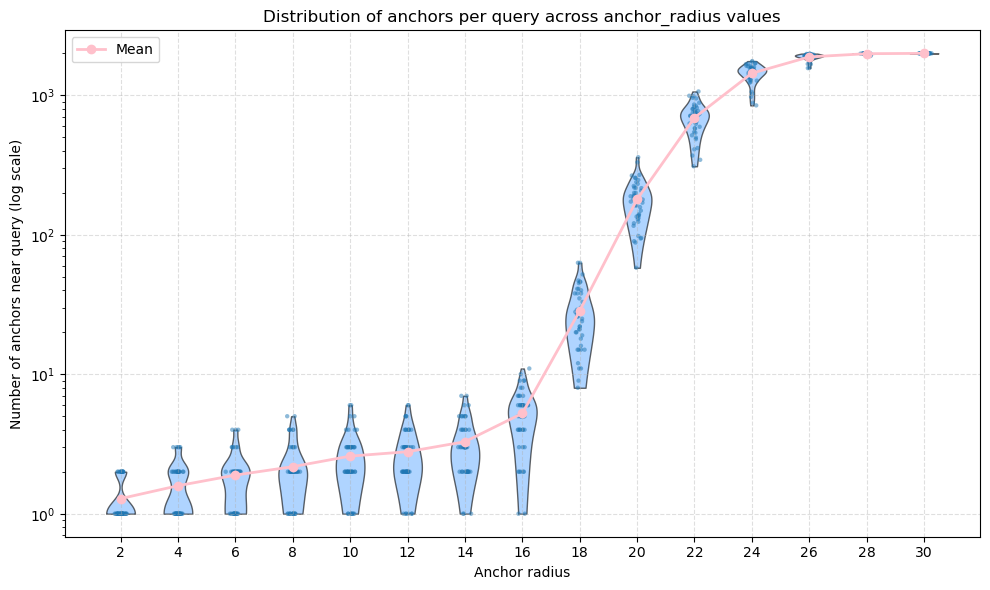

In [3]:
# 大循环：尝试不同 anchor 数量
for num_anchor in [100, 500, 1000, 2000]:
    for radius in anchor_radii:
        print(f"Running with anchor_radius = {radius}...")
        cmd = [
            EXECUTABLE,
            "--num_anchors", str(num_anchor),
            "--truncate_ref_len", "10000",
            "--anchor_len", "40",
            "--num_queries", "100",
            "--maxDist", "2",
            "--anchor_radius", str(radius)
        ]
        print("cmd:", cmd)

        # 调用可执行程序
        proc = subprocess.run(cmd, capture_output=True, text=True)
        if proc.returncode != 0:
            print(f"Error running {cmd}: {proc.stderr}")
            continue

        output = proc.stdout

        # 输出文件假设程序写成 dist_counts.txt
        counts_file = f"./dist_counts_radius_{radius}.txt"
        if not os.path.exists(counts_file):
            print(f"⚠️ {counts_file} not found for anchor_radius={radius}")
            continue

        with open(counts_file) as f:
            counts = [int(line.strip()) for line in f]

        all_counts[radius] = counts

        # 解析指标
        metrics = {}
        patterns = {
            "avg_tp": r"Average TP:\s*([0-9.eE+-]+)",
            "avg_fp": r"Average FP:\s*([0-9.eE+-]+)",
            "avg_fn": r"Average FN:\s*([0-9.eE+-]+)",
            "avg_recall": r"Average Recall:\s*([0-9.eE+-]+)",
            "avg_precision": r"Average Precision:\s*([0-9.eE+-]+)",
            "avg_fp_over_tp": r"Average FP/TP:\s*([0-9.eE+-]+)",
            "avg_avg_dist": r"Average average distance:\s*([0-9.eE+-]+)",
            "avg_max_dist": r"Average maximum distance:\s*([0-9.eE+-]+)"
        }

        for key, pat in patterns.items():
            m = re.search(pat, output)
            metrics[key] = float(m.group(1)) if m else None

        all_metrics[radius] = metrics

    # 保存所有 dist_list 结果到 CSV
    df_list = []
    for radius, counts in all_counts.items():
        for c in counts:
            df_list.append({"anchor_radius": radius, "num_anchors_near_query": c})
    df = pd.DataFrame(df_list)
    df.to_csv("./csv/dist_counts_sweep.csv", index=False)

    # 获取所有 anchor_radius 的唯一值
    radii = df['anchor_radius'].unique()

    for radius in radii:
        counts = df[df['anchor_radius'] == radius]['num_anchors_near_query']

        plt.figure(figsize=(8,5))
        plt.hist(counts, bins=range(min(counts), max(counts)+2), color='skyblue')
        plt.xlabel("Number of anchors within radius")
        plt.ylabel("Number of queries")
        plt.title(f"Distribution of anchors per query (anchor_radius={radius})")

        # 在图上标注指标
        if radius in all_metrics:
            metric_text = "\n".join([f"{k}: {v:.2f}" for k, v in all_metrics[radius].items()])
            plt.gcf().text(0.7, 0.6, metric_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.6))

        # 保存图像
        plt.savefig(f"./fig/dist_counts_anchor_{num_anchor}_radius_{radius}.png")
        plt.show()
        plt.close()

    

    # 构建 DataFrame，只保留关注的五个指标
    metrics_list = []
    for radius, metrics in all_metrics.items():
        metrics_copy = {k: metrics[k] for k in [
            "avg_recall", "avg_precision", "avg_tp", "avg_fp", "avg_fp_over_tp", "avg_avg_dist", "avg_max_dist"
        ]}
        metrics_copy['anchor_radius'] = radius
        metrics_list.append(metrics_copy)

    metrics_df = pd.DataFrame(metrics_list)
    metrics_df = metrics_df.sort_values('anchor_radius')

    # 创建三个 subplot
    fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=False)

    # subplot 1: Recall 和 Precision
    axs[0].plot(metrics_df['anchor_radius'], metrics_df['avg_recall'], marker='o', label='Recall')
    axs[0].plot(metrics_df['anchor_radius'], metrics_df['avg_precision'], marker='s', label='Precision')
    axs[0].set_ylabel("Value")
    axs[0].set_title("Recall & Precision vs Anchor Radius")
    axs[0].grid(True)
    axs[0].legend()

    # subplot 2: FP, TP, FP/TP
    # 这里假设 TP 可以从 FP/TP 和 FP 计算，或者如果有 avg_tp 指标也可直接用
    # 先画 FP/TP
    axs[1].plot(metrics_df['anchor_radius'], metrics_df['avg_tp'], marker='o', label='TP')
    axs[1].plot(metrics_df['anchor_radius'], metrics_df['avg_fp'], marker='o', label='FP')
    axs[1].plot(metrics_df['anchor_radius'], metrics_df['avg_fp_over_tp'], marker='o', label='FP/TP')
    axs[1].set_ylabel("Value")
    axs[1].set_title("FP/TP vs Anchor Radius")
    axs[1].grid(True)
    axs[1].legend()

    # subplot 3: avg_dist 和 max_dist
    axs[2].plot(metrics_df['anchor_radius'], metrics_df['avg_avg_dist'], marker='o', label='Avg Distance')
    axs[2].plot(metrics_df['anchor_radius'], metrics_df['avg_max_dist'], marker='s', label='Max Distance')
    axs[2].set_xlabel("Anchor Radius")
    axs[2].set_ylabel("Distance")
    axs[2].set_title("Average & Maximum Distance vs Anchor Radius")
    axs[2].grid(True)
    axs[2].legend()

    plt.tight_layout()
    plt.savefig(f"./fig/metrics_three_subplots_anchor_{num_anchor}.png")
    plt.show()

    # ----------- 小提琴图 -------------

    # 读取数据
    csv_path = "./csv/dist_counts_sweep.csv"
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"{csv_path} not found!")
    df = pd.read_csv(csv_path)

    # 按 anchor_radius 排序并组织数据
    radii_sorted = sorted(df['anchor_radius'].unique())
    data = [df[df['anchor_radius'] == r]['num_anchors_near_query'].values for r in radii_sorted]

    # 创建图
    fig, ax = plt.subplots(figsize=(10, 6))

    # -------------------
    # 小提琴图
    # -------------------
    parts = ax.violinplot(
        data,
        positions=range(1, len(radii_sorted) + 1),
        showmeans=False,
        showextrema=False,
        showmedians=False
    )

    for pc in parts['bodies']:
        pc.set_facecolor("#7ab8ff")
        pc.set_edgecolor("black")
        pc.set_alpha(0.6)

    # -------------------
    # 散点图（带抖动）
    # -------------------
    for i, y in enumerate(data):
        x = np.random.normal(i + 1, 0.05, size=len(y))  # 抖动
        ax.scatter(x, y, alpha=0.5, s=10, color="tab:blue", edgecolor="none")

    # -------------------
    # 平均值折线
    # -------------------
    means = [np.mean(y) for y in data]
    ax.plot(range(1, len(radii_sorted) + 1), means, marker="o", color="pink", linewidth=2, label="Mean")

    # -------------------
    # 样式设置
    # -------------------
    ax.set_xticks(range(1, len(radii_sorted) + 1))
    ax.set_xticklabels(radii_sorted)
    ax.set_xlabel("Anchor radius")
    ax.set_ylabel("Number of anchors near query (log scale)")
    ax.set_title("Distribution of anchors per query across anchor_radius values")
    ax.set_yscale("log")
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend()

    plt.tight_layout()
    os.makedirs("./fig", exist_ok=True)
    plt.savefig(f"./fig/violin_scatter_num_anchors_per_radius_log_anchor_{num_anchor}.png", dpi=300)
    plt.show()

In [8]:
for radius in anchor_radii:
    print(f"Running with anchor_radius = {radius}...")
    cmd = [
        EXECUTABLE,
        "--num_anchors", "2000",
        "--truncate_ref_len", "10000",
        "--anchor_len", "40",
        "--num_queries", "100",
        "--maxDist", "2",
        "--anchor_radius", str(radius)
    ]
    print("cmd:", cmd)

    # 调用可执行程序
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 输出文件假设程序写成 dist_counts.txt
    counts_file = f"./dist_counts_radius_{radius}.txt"
    if not os.path.exists(counts_file):
        print(f"⚠️ {counts_file} not found for anchor_radius={radius}")
        continue

    with open(counts_file) as f:
        counts = [int(line.strip()) for line in f]

    all_counts[radius] = counts

    # 解析指标
    metrics = {}
    patterns = {
        "avg_tp": r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp": r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn": r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall": r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision": r"Average Precision:\s*([0-9.eE+-]+)",
        "avg_fp_over_tp": r"Average FP/TP:\s*([0-9.eE+-]+)",
        "avg_avg_dist": r"Average average distance:\s*([0-9.eE+-]+)",
        "avg_max_dist": r"Average maximum distance:\s*([0-9.eE+-]+)"
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        metrics[key] = float(m.group(1)) if m else None

    all_metrics[radius] = metrics

# 保存所有 dist_list 结果到 CSV
df_list = []
for radius, counts in all_counts.items():
    for c in counts:
        df_list.append({"anchor_radius": radius, "num_anchors_near_query": c})
df = pd.DataFrame(df_list)
df.to_csv("./csv/dist_counts_sweep.csv", index=False)

# 获取所有 anchor_radius 的唯一值
radii = df['anchor_radius'].unique()

for radius in radii:
    counts = df[df['anchor_radius'] == radius]['num_anchors_near_query']

    plt.figure(figsize=(8,5))
    plt.hist(counts, bins=range(min(counts), max(counts)+2), color='skyblue')
    plt.xlabel("Number of anchors within radius")
    plt.ylabel("Number of queries")
    plt.title(f"Distribution of anchors per query (anchor_radius={radius})")

    # 在图上标注指标
    if radius in all_metrics:
        metric_text = "\n".join([f"{k}: {v:.2f}" for k, v in all_metrics[radius].items()])
        plt.gcf().text(0.7, 0.6, metric_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.6))

    # 保存图像
    plt.savefig(f"./fig/dist_counts_radius_{radius}.png")
    plt.show()
    plt.close()

Running with anchor_radius = 2...
cmd: ['../anchor_mapping', '--num_anchors', '2000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '2']
Running with anchor_radius = 4...
cmd: ['../anchor_mapping', '--num_anchors', '2000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '4']
Running with anchor_radius = 6...
cmd: ['../anchor_mapping', '--num_anchors', '2000', '--truncate_ref_len', '10000', '--anchor_len', '40', '--num_queries', '100', '--maxDist', '2', '--anchor_radius', '6']


KeyboardInterrupt: 

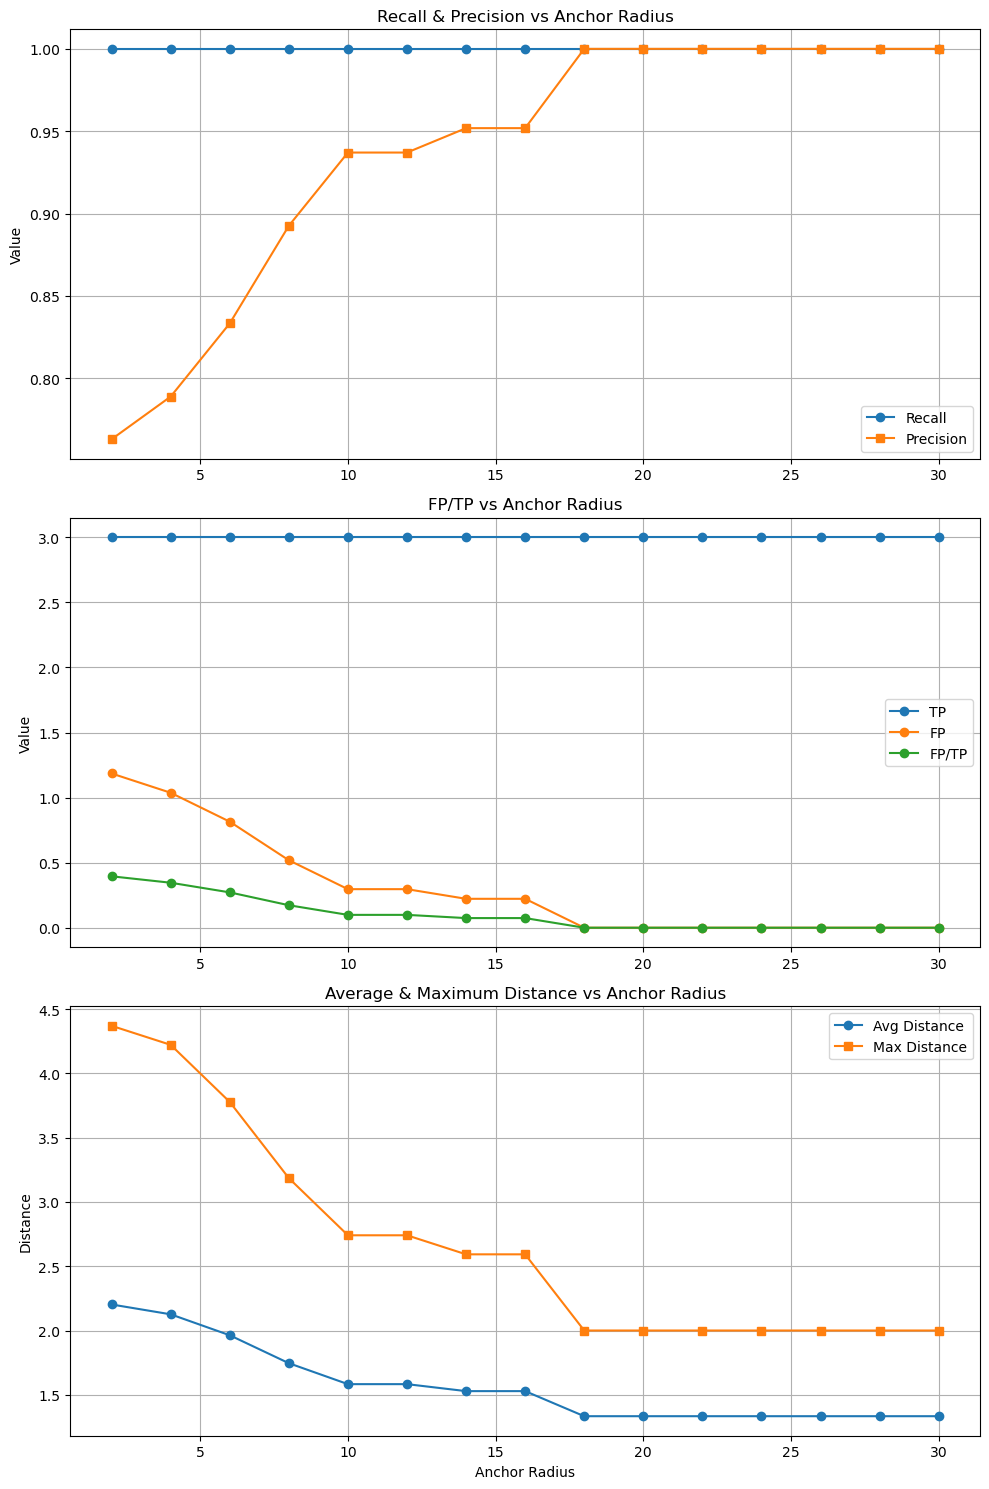

In [ ]:


# 构建 DataFrame，只保留关注的五个指标
metrics_list = []
for radius, metrics in all_metrics.items():
    metrics_copy = {k: metrics[k] for k in [
        "avg_recall", "avg_precision", "avg_tp", "avg_fp", "avg_fp_over_tp", "avg_avg_dist", "avg_max_dist"
    ]}
    metrics_copy['anchor_radius'] = radius
    metrics_list.append(metrics_copy)

metrics_df = pd.DataFrame(metrics_list)
metrics_df = metrics_df.sort_values('anchor_radius')

# 创建三个 subplot
fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=False)

# subplot 1: Recall 和 Precision
axs[0].plot(metrics_df['anchor_radius'], metrics_df['avg_recall'], marker='o', label='Recall')
axs[0].plot(metrics_df['anchor_radius'], metrics_df['avg_precision'], marker='s', label='Precision')
axs[0].set_ylabel("Value")
axs[0].set_title("Recall & Precision vs Anchor Radius")
axs[0].grid(True)
axs[0].legend()

# subplot 2: FP, TP, FP/TP
# 这里假设 TP 可以从 FP/TP 和 FP 计算，或者如果有 avg_tp 指标也可直接用
# 先画 FP/TP
axs[1].plot(metrics_df['anchor_radius'], metrics_df['avg_tp'], marker='o', label='TP')
axs[1].plot(metrics_df['anchor_radius'], metrics_df['avg_fp'], marker='o', label='FP')
axs[1].plot(metrics_df['anchor_radius'], metrics_df['avg_fp_over_tp'], marker='o', label='FP/TP')
axs[1].set_ylabel("Value")
axs[1].set_title("FP/TP vs Anchor Radius")
axs[1].grid(True)
axs[1].legend()

# subplot 3: avg_dist 和 max_dist
axs[2].plot(metrics_df['anchor_radius'], metrics_df['avg_avg_dist'], marker='o', label='Avg Distance')
axs[2].plot(metrics_df['anchor_radius'], metrics_df['avg_max_dist'], marker='s', label='Max Distance')
axs[2].set_xlabel("Anchor Radius")
axs[2].set_ylabel("Distance")
axs[2].set_title("Average & Maximum Distance vs Anchor Radius")
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.savefig("./fig/metrics_three_subplots.png")
plt.show()

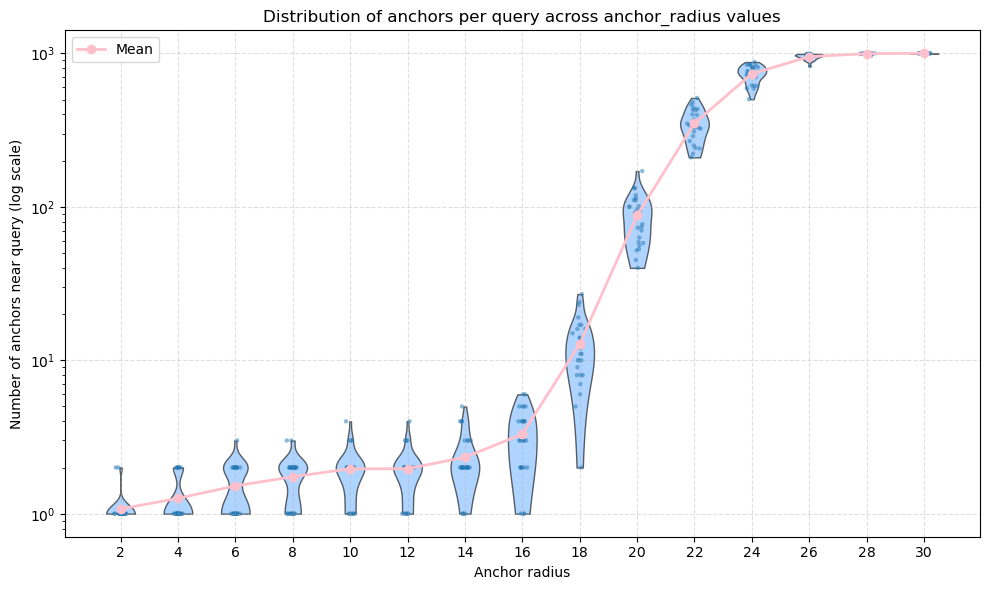

In [ ]:

# 读取数据
csv_path = "./csv/dist_counts_sweep.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"{csv_path} not found!")
df = pd.read_csv(csv_path)

# 按 anchor_radius 排序并组织数据
radii_sorted = sorted(df['anchor_radius'].unique())
data = [df[df['anchor_radius'] == r]['num_anchors_near_query'].values for r in radii_sorted]

# 创建图
fig, ax = plt.subplots(figsize=(10, 6))

# -------------------
# 小提琴图
# -------------------
parts = ax.violinplot(
    data,
    positions=range(1, len(radii_sorted) + 1),
    showmeans=False,
    showextrema=False,
    showmedians=False
)

for pc in parts['bodies']:
    pc.set_facecolor("#7ab8ff")
    pc.set_edgecolor("black")
    pc.set_alpha(0.6)

# -------------------
# 散点图（带抖动）
# -------------------
for i, y in enumerate(data):
    x = np.random.normal(i + 1, 0.05, size=len(y))  # 抖动
    ax.scatter(x, y, alpha=0.5, s=10, color="tab:blue", edgecolor="none")

# -------------------
# 平均值折线
# -------------------
means = [np.mean(y) for y in data]
ax.plot(range(1, len(radii_sorted) + 1), means, marker="o", color="pink", linewidth=2, label="Mean")

# -------------------
# 样式设置
# -------------------
ax.set_xticks(range(1, len(radii_sorted) + 1))
ax.set_xticklabels(radii_sorted)
ax.set_xlabel("Anchor radius")
ax.set_ylabel("Number of anchors near query (log scale)")
ax.set_title("Distribution of anchors per query across anchor_radius values")
ax.set_yscale("log")
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
os.makedirs("./fig", exist_ok=True)
plt.savefig("./fig/violin_scatter_num_anchors_per_radius_log.png", dpi=300)
plt.show()

Loaded 1000 anchors and 100 queries


Computing nearest anchor distance: 100%|██████████| 100/100 [00:00<00:00, 1940.41it/s]


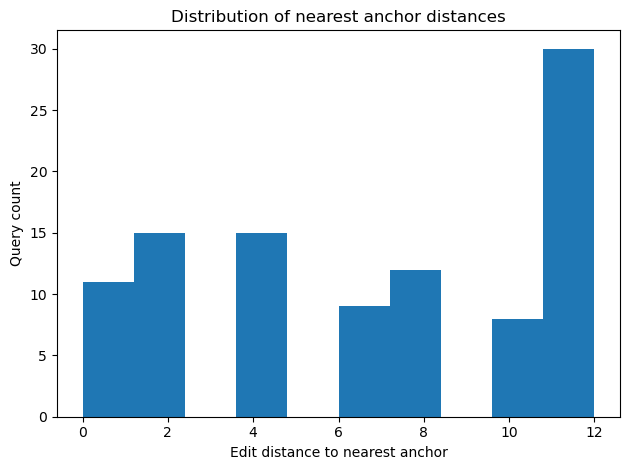

Computing top-n anchor distances: 100%|██████████| 100/100 [00:00<00:00, 1734.02it/s]


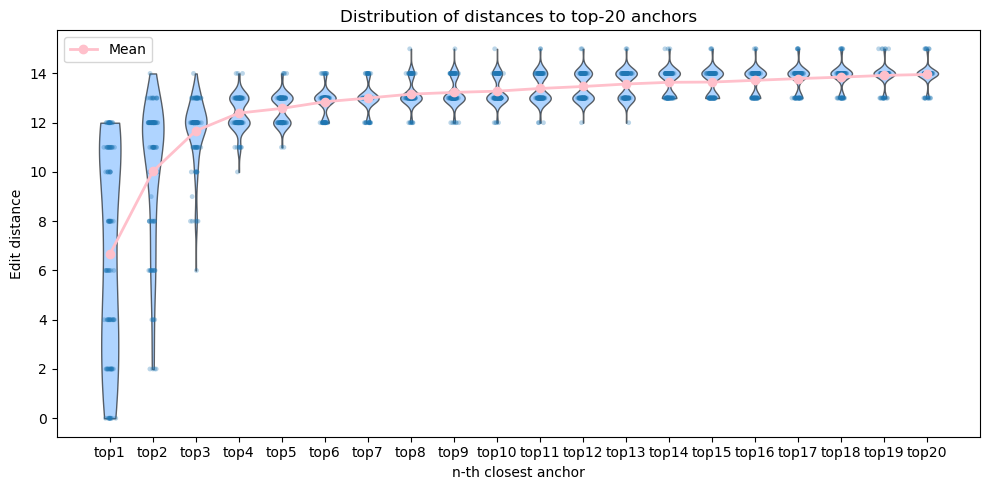

Anchor-anchor distances: 100%|██████████| 499500/499500 [00:00<00:00, 1530531.92it/s]


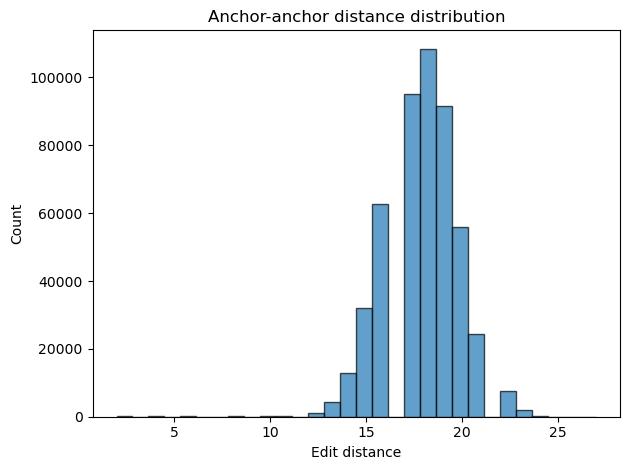

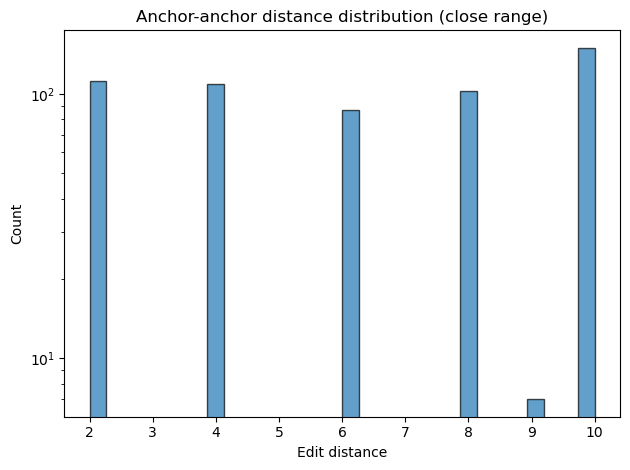

In [5]:
plot_anchor_stats("../anchor_index.json", n_top=20)